# E5: MedVAE-re — tiny-image-net

基于 `sSegUnet-medvae-sd-cifar10 copy.ipynb`。训练 **vae / sd(ours) / iwae** 三种算法：保留 medvae 的全部 loss 项 (L1 重建 + LPIPS + GAN 判别器)，仅把 KL 正则项替换为 Score Divergence (Dq+KL_t) 或 IWAE bound。

## lib

In [1]:
# ==========================================
# 1. 导入所有必需的库
# ==========================================
import os
import sys
import math
import numpy as np
from PIL import Image
from collections import namedtuple
import functools

import datasets
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import make_grid
import torchvision.transforms.functional as TF
from einops import rearrange
from tqdm import tqdm
import requests
from datetime import datetime

# ==========================================
# 2. 配置参数
# ==========================================
time_now = datetime.now().strftime("%m-%d_%H-%M")
RUN_FAMILY = "medvae-re"  # medvae 全部 loss 项不变，仅替换 KL 正则项 (vae/sd/iwae)

class Config:
    DATASET_NAME = "tiny-image-net"
    DATASET_DIR = "/home/yzm/data_tiny_image_net"
    TRAIN_DATASET_DIR = os.path.join(DATASET_DIR, "train")
    TEST_DATASET_DIR = os.path.join(DATASET_DIR, "test")
    VAL_SPLIT_RATIO = 0.1
    SPLIT_SEED = 42
    IMAGE_KEY = "image"
    IMG_SIZE = 64
    IMG_CHANNELS = 3
    BATCH_SIZE = 32
    BASE_LEARNING_RATE = 4.5e-6
    NUM_WORKERS = 4
    MAX_EPOCHS = 10
    SAVE_DIR = f"/home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-{time_now}"
    CUDA_NUM = 2

config = Config()
os.makedirs(config.SAVE_DIR, exist_ok=True)

device = torch.device(f"cuda:{config.CUDA_NUM}" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Run family: {RUN_FAMILY}")
print(f"Dataset: {config.DATASET_NAME} ({config.IMG_SIZE}x{config.IMG_SIZE}x{config.IMG_CHANNELS})")
print(f"Dataset dir: {config.DATASET_DIR}")
print(f"Validation split: {1 - config.VAL_SPLIT_RATIO:.0%}/{config.VAL_SPLIT_RATIO:.0%} (seed={config.SPLIT_SEED})")
print(f"Save dir: {config.SAVE_DIR}")


Using device: cuda:2
Run family: medvae-re
Dataset: tiny-image-net (64x64x3)
Dataset dir: /home/yzm/data_tiny_image_net
Validation split: 90%/10% (seed=42)
Save dir: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08


## MedVAE 

In [2]:
# ==========================================
# MedVAE 核心组件: Encoder & Decoder
# ==========================================

def nonlinearity(x):
    """Swish激活函数"""
    return x * torch.sigmoid(x)

def Normalize(in_channels, num_groups=32):
    return nn.GroupNorm(num_groups=num_groups, num_channels=in_channels, eps=1e-6, affine=True)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x)
        q, k, v = rearrange(qkv, "b (qkv heads c) h w -> qkv b heads c (h w)", heads=self.heads, qkv=3)
        k = k.softmax(dim=-1)
        context = torch.einsum("bhdn,bhen->bhde", k, v)
        out = torch.einsum("bhde,bhdn->bhen", context, q)
        out = rearrange(out, "b heads c (h w) -> b (heads c) h w", heads=self.heads, h=h, w=w)
        return self.to_out(out)

class LinAttnBlock(LinearAttention):
    def __init__(self, in_channels):
        super().__init__(dim=in_channels, heads=1, dim_head=in_channels)

class AttnBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.in_channels = in_channels
        self.norm = Normalize(in_channels)
        self.q = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.k = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.v = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.proj_out = nn.Conv2d(in_channels, in_channels, kernel_size=1)

    def forward(self, x):
        h_ = self.norm(x)
        q, k, v = self.q(h_), self.k(h_), self.v(h_)
        b, c, h, w = q.shape
        q = q.reshape(b, c, h * w).permute(0, 2, 1)
        k = k.reshape(b, c, h * w)
        w_ = torch.bmm(q, k) * (int(c) ** (-0.5))
        w_ = F.softmax(w_, dim=2)
        v = v.reshape(b, c, h * w)
        w_ = w_.permute(0, 2, 1)
        h_ = torch.bmm(v, w_).reshape(b, c, h, w)
        return x + self.proj_out(h_)

def make_attn(in_channels, attn_type="vanilla"):
    if attn_type == "vanilla":
        return AttnBlock(in_channels)
    elif attn_type == "none":
        return nn.Identity(in_channels)
    else:
        return LinAttnBlock(in_channels)

class Upsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="nearest")
        if self.with_conv:
            x = self.conv(x)
        return x

class Downsample(nn.Module):
    def __init__(self, in_channels, with_conv):
        super().__init__()
        self.with_conv = with_conv
        if self.with_conv:
            self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=2, padding=0)

    def forward(self, x):
        if self.with_conv:
            x = F.pad(x, (0, 1, 0, 1), mode="constant", value=0)
            x = self.conv(x)
        else:
            x = F.avg_pool2d(x, kernel_size=2, stride=2)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, *, in_channels, out_channels=None, conv_shortcut=False, dropout, temb_channels=512):
        super().__init__()
        self.in_channels = in_channels
        out_channels = in_channels if out_channels is None else out_channels
        self.out_channels = out_channels
        self.use_conv_shortcut = conv_shortcut

        self.norm1 = Normalize(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        if temb_channels > 0:
            self.temb_proj = nn.Linear(temb_channels, out_channels)
        self.norm2 = Normalize(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        
        if self.in_channels != self.out_channels:
            if self.use_conv_shortcut:
                self.conv_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
            else:
                self.nin_shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)

    def forward(self, x, temb):
        h = nonlinearity(self.norm1(x))
        h = self.conv1(h)
        if temb is not None:
            h = h + self.temb_proj(nonlinearity(temb))[:, :, None, None]
        h = nonlinearity(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        if self.in_channels != self.out_channels:
            x = self.conv_shortcut(x) if self.use_conv_shortcut else self.nin_shortcut(x)
        return x + h

In [3]:
# ==========================================
# Encoder 和 Decoder 类
# ==========================================

class Encoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 double_z=True, use_linear_attn=False, attn_type="vanilla", **ignore_kwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels

        # downsampling
        self.conv_in = nn.Conv2d(in_channels, self.ch, kernel_size=3, stride=1, padding=1)
        curr_res = resolution
        in_ch_mult = (1,) + tuple(ch_mult)
        self.down = nn.ModuleList()
        
        for i_level in range(self.num_resolutions):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_in = ch * in_ch_mult[i_level]
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            down = nn.Module()
            down.block = block
            down.attn = attn
            if i_level != self.num_resolutions - 1:
                down.downsample = Downsample(block_in, resamp_with_conv)
                curr_res = curr_res // 2
            self.down.append(down)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, 2 * z_channels if double_z else z_channels, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        temb = None
        hs = [self.conv_in(x)]
        for i_level in range(self.num_resolutions):
            for i_block in range(self.num_res_blocks):
                h = self.down[i_level].block[i_block](hs[-1], temb)
                if len(self.down[i_level].attn) > 0:
                    h = self.down[i_level].attn[i_block](h)
                hs.append(h)
            if i_level != self.num_resolutions - 1:
                hs.append(self.down[i_level].downsample(hs[-1]))
        h = hs[-1]
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        return h


class Decoder(nn.Module):
    def __init__(self, *, ch, out_ch, ch_mult=(1, 2, 4, 8), num_res_blocks, attn_resolutions,
                 dropout=0.0, resamp_with_conv=True, in_channels, resolution, z_channels,
                 give_pre_end=False, tanh_out=False, use_linear_attn=False, attn_type="vanilla", **ignorekwargs):
        super().__init__()
        if use_linear_attn:
            attn_type = "linear"
        self.ch = ch
        self.temb_ch = 0
        self.num_resolutions = len(ch_mult)
        self.num_res_blocks = num_res_blocks
        self.resolution = resolution
        self.in_channels = in_channels
        self.give_pre_end = give_pre_end
        self.tanh_out = tanh_out

        block_in = ch * ch_mult[self.num_resolutions - 1]
        curr_res = resolution // 2 ** (self.num_resolutions - 1)

        # z to block_in
        self.conv_in = nn.Conv2d(z_channels, block_in, kernel_size=3, stride=1, padding=1)

        # middle
        self.mid = nn.Module()
        self.mid.block_1 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)
        self.mid.attn_1 = make_attn(block_in, attn_type=attn_type)
        self.mid.block_2 = ResnetBlock(in_channels=block_in, out_channels=block_in, temb_channels=self.temb_ch, dropout=dropout)

        # upsampling
        self.up = nn.ModuleList()
        for i_level in reversed(range(self.num_resolutions)):
            block = nn.ModuleList()
            attn = nn.ModuleList()
            block_out = ch * ch_mult[i_level]
            for i_block in range(self.num_res_blocks + 1):
                block.append(ResnetBlock(in_channels=block_in, out_channels=block_out, temb_channels=self.temb_ch, dropout=dropout))
                block_in = block_out
                if curr_res in attn_resolutions:
                    attn.append(make_attn(block_in, attn_type=attn_type))
            up = nn.Module()
            up.block = block
            up.attn = attn
            if i_level != 0:
                up.upsample = Upsample(block_in, resamp_with_conv)
                curr_res = curr_res * 2
            self.up.insert(0, up)

        # end
        self.norm_out = Normalize(block_in)
        self.conv_out = nn.Conv2d(block_in, out_ch, kernel_size=3, stride=1, padding=1)

    def forward(self, z):
        temb = None
        h = self.conv_in(z)
        h = self.mid.block_1(h, temb)
        h = self.mid.attn_1(h)
        h = self.mid.block_2(h, temb)
        for i_level in reversed(range(self.num_resolutions)):
            for i_block in range(self.num_res_blocks + 1):
                h = self.up[i_level].block[i_block](h, temb)
                if len(self.up[i_level].attn) > 0:
                    h = self.up[i_level].attn[i_block](h)
            if i_level != 0:
                h = self.up[i_level].upsample(h)
        if self.give_pre_end:
            return h
        h = self.norm_out(h)
        h = nonlinearity(h)
        h = self.conv_out(h)
        if self.tanh_out:
            h = torch.tanh(h)
        return h

In [4]:
# ==========================================
# DiagonalGaussianDistribution (潜在空间分布)
# ==========================================

class DiagonalGaussianDistribution:
    def __init__(self, parameters, deterministic=False):
        self.parameters = parameters
        self.mean, self.logvar = torch.chunk(parameters, 2, dim=1)
        self.logvar = torch.clamp(self.logvar, -30.0, 20.0)
        self.deterministic = deterministic
        self.std = torch.exp(0.5 * self.logvar)
        self.var = torch.exp(self.logvar)
        if self.deterministic:
            self.var = self.std = torch.zeros_like(self.mean).to(device=self.parameters.device)

    def sample(self):
        x = self.mean + self.std * torch.randn(self.mean.shape).to(device=self.parameters.device)
        return x

    def kl(self, other=None):
        if self.deterministic:
            return torch.Tensor([0.0])
        if other is None:
            return 0.5 * torch.sum(torch.pow(self.mean, 2) + self.var - 1.0 - self.logvar, dim=[1, 2, 3])
        else:
            return 0.5 * torch.sum(
                torch.pow(self.mean - other.mean, 2) / other.var + self.var / other.var - 1.0 - self.logvar + other.logvar,
                dim=[1, 2, 3],
            )

    def nll(self, sample, dims=[1, 2, 3]):
        if self.deterministic:
            return torch.Tensor([0.0])
        logtwopi = np.log(2.0 * np.pi)
        return 0.5 * torch.sum(logtwopi + self.logvar + torch.pow(sample - self.mean, 2) / self.var, dim=dims)

    def mode(self):
        return self.mean

## data

In [5]:
# ==========================================
# tiny-image-net Hugging Face 数据集 (VAE训练用，归一化到[-1,1])
# ==========================================
from datasets import Image as HFImage
class HFImageDataset(Dataset):
    """
    Hugging Face tiny-image-net 数据集封装
    输出图像归一化到 [-1, 1] 范围
    """
    def __init__(self, split='train', augment=False):
        split_to_path = {
            'train': config.TRAIN_DATASET_DIR,
            'test': config.TEST_DATASET_DIR,
        }
        if split not in split_to_path:
            raise ValueError(f"Unsupported split: {split}")

        self.split = split
        self.dataset_path = split_to_path[split]
        self.image_key = config.IMAGE_KEY
        self.dataset = datasets.load_from_disk(self.dataset_path)
        # tiny-image-net: 确保 image 列按 PIL 图像解码 (同 14x notebook 的 cast_column)
        self.dataset = self.dataset.cast_column(self.image_key, HFImage(decode=True))
        transform_ops = [
            transforms.Resize(config.IMG_SIZE),
            transforms.CenterCrop(config.IMG_SIZE),
        ]
        if augment:
            transform_ops.append(transforms.RandomHorizontalFlip())
        transform_ops.extend([
            transforms.ToTensor(),
            transforms.Normalize([0.5] * config.IMG_CHANNELS, [0.5] * config.IMG_CHANNELS),
        ])
        self.transform = transforms.Compose(transform_ops)

        print(f"[{self.split}] 数据集路径: {self.dataset_path}")
        print(f"[{self.split}] 数据集大小: {len(self.dataset)}")
        print(f"[{self.split}] 数据集列: {self.dataset.column_names}")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img = self.dataset[idx][self.image_key]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.array(img))
        img = img.convert("RGB" if config.IMG_CHANNELS == 3 else "L")
        return self.transform(img)


## vae class

In [6]:
# ==========================================
# AutoencoderKL 模型 (更适合 CIFAR10 重建的配置)
# ==========================================

class AutoencoderKL(nn.Module):
    """
    2D VAE 模型
    - 4x 空间压缩
    - RGB 三通道输入
    - 更大的潜在容量用于提升 CIFAR10 重建质量
    """
    def __init__(self, ddconfig, embed_dim, ckpt_path=None, ignore_keys=[], apply_channel_ds=False):
        super().__init__()
        self.encoder = Encoder(**ddconfig)
        self.decoder = Decoder(**ddconfig)

        assert ddconfig["double_z"]
        self.quant_conv = nn.Conv2d(2 * ddconfig["z_channels"], 2 * embed_dim, 1)
        self.post_quant_conv = nn.Conv2d(embed_dim, ddconfig["z_channels"], 1)
        self.embed_dim = embed_dim
        self.latent_downsample_factor = 2 ** (len(ddconfig["ch_mult"]) - 1)
        self.latent_resolution = ddconfig["resolution"] // self.latent_downsample_factor

        self.apply_channel_ds = apply_channel_ds
        if self.apply_channel_ds:
            self.channel_ds = nn.Sequential(
                nn.Conv2d(self.embed_dim, 64, 1),
                nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding="same"),
                nn.ReLU(),
                nn.Conv2d(64, self.embed_dim, 1),
            )
            self.channel_proj = nn.Conv2d(self.embed_dim, self.embed_dim, 1)

        if ckpt_path is not None:
            self.init_from_ckpt(ckpt_path, ignore_keys=ignore_keys)

    def init_from_ckpt(self, path, ignore_keys=[]):
        sd = torch.load(path, map_location="cpu")
        if "state_dict" in sd:
            sd = sd["state_dict"]
        keys = list(sd.keys())
        for k in keys:
            for ik in ignore_keys:
                if k.startswith(ik):
                    print(f"Deleting key {k} from state_dict.")
                    del sd[k]
        self.load_state_dict(sd, strict=False)
        print(f"Restored from {path}")

    def encode(self, x):
        """编码: 图像 -> 潜在分布"""
        h = self.encoder(x)
        moments = self.quant_conv(h)
        posterior = DiagonalGaussianDistribution(moments)
        return posterior

    def decode(self, z):
        """解码: 潜在向量 -> 图像"""
        z = self.post_quant_conv(z)
        dec = self.decoder(z)
        return dec

    def forward(self, input, sample_posterior=True):
        """前向传播"""
        posterior = self.encode(input)
        if sample_posterior:
            z = posterior.sample()
        else:
            z = posterior.mode()

        if self.apply_channel_ds:
            z = self.channel_proj(self.channel_ds(z) + z)

        dec = self.decode(z)
        return dec, posterior, z

    def get_last_layer(self):
        """获取decoder最后一层权重 (用于自适应权重计算)"""
        return self.decoder.conv_out.weight


ddconfig = {
    "double_z": True,
    "z_channels": 4,
    "resolution": config.IMG_SIZE,
    "in_channels": config.IMG_CHANNELS,
    "out_ch": config.IMG_CHANNELS,
    "ch": 32,
    "ch_mult": [1, 2],
    "num_res_blocks": 2,
    "attn_resolutions": [config.IMG_SIZE // 2],  # 与基准 cifar10 (32//2=16) 一致，按分辨率适配
    "dropout": 0.0
}
embed_dim = 4
latent_downsample_factor = 2 ** (len(ddconfig["ch_mult"]) - 1)
latent_resolution = ddconfig["resolution"] // latent_downsample_factor

print(f"模型配置: medvae_{config.DATASET_NAME}_recon")
print(f"  输入分辨率: {ddconfig['resolution']}x{ddconfig['resolution']}")
print(f"  输入通道: {ddconfig['in_channels']}")
print(f"  潜在空间: {embed_dim} 通道, {latent_resolution}x{latent_resolution} 分辨率")
print(f"  空间下采样倍数: {latent_downsample_factor}x")

模型配置: medvae_tiny-image-net_recon
  输入分辨率: 64x64
  输入通道: 3
  潜在空间: 4 通道, 32x32 分辨率
  空间下采样倍数: 2x


## loss

In [7]:
# ==========================================
# LPIPS 感知损失 + 判别器
# ==========================================

def hinge_loss(logits_real, logits_fake):
    """Hinge loss for discriminator"""
    loss_real = torch.mean(F.relu(1.0 - logits_real))
    loss_fake = torch.mean(F.relu(1.0 + logits_fake))
    return 0.5 * (loss_real + loss_fake)

class ScalingLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("shift", torch.Tensor([-0.030, -0.088, -0.188])[None, :, None, None])
        self.register_buffer("scale", torch.Tensor([0.458, 0.448, 0.450])[None, :, None, None])

    def forward(self, inp):
        return (inp - self.shift) / self.scale

class NetLinLayer(nn.Module):
    def __init__(self, chn_in, chn_out=1, use_dropout=False):
        super().__init__()
        layers = [nn.Dropout()] if use_dropout else []
        layers += [nn.Conv2d(chn_in, chn_out, 1, stride=1, padding=0, bias=False)]
        self.model = nn.Sequential(*layers)

class vgg16(nn.Module):
    def __init__(self, requires_grad=False):
        super().__init__()
        vgg_pretrained_features = models.vgg16(weights="VGG16_Weights.IMAGENET1K_V1").features
        self.slice1 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(4)])
        self.slice2 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(4, 9)])
        self.slice3 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(9, 16)])
        self.slice4 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(16, 23)])
        self.slice5 = nn.Sequential(*[vgg_pretrained_features[x] for x in range(23, 30)])
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_2 = h
        h = self.slice2(h)
        h_relu2_2 = h
        h = self.slice3(h)
        h_relu3_3 = h
        h = self.slice4(h)
        h_relu4_3 = h
        h = self.slice5(h)
        h_relu5_3 = h
        return namedtuple("VggOutputs", ["relu1_2", "relu2_2", "relu3_3", "relu4_3", "relu5_3"])(
            h_relu1_2, h_relu2_2, h_relu3_3, h_relu4_3, h_relu5_3
        )

def normalize_tensor(x, eps=1e-10):
    return x / (torch.sqrt(torch.sum(x**2, dim=1, keepdim=True)) + eps)

def spatial_average(x, keepdim=True):
    return x.mean([2, 3], keepdim=keepdim)

def get_ckpt_path(name, root, check=False):
    """下载VGG LPIPS权重"""
    vgg_url = "https://heibox.uni-heidelberg.de/f/607503859c864bc1b30b/?dl=1"
    path = os.path.join(root, "vgg.pth")
    if not os.path.exists(path):
        print(f"Downloading {name} model from {vgg_url} to {path}")
        os.makedirs(root, exist_ok=True)
        with requests.get(vgg_url, stream=True) as r:
            total_size = int(r.headers.get("content-length", 0))
            with tqdm(total=total_size, unit="B", unit_scale=True) as pbar:
                with open(path, "wb") as f:
                    for data in r.iter_content(chunk_size=1024):
                        if data:
                            f.write(data)
                            pbar.update(len(data))
    return path

class LPIPS(nn.Module):
    """LPIPS感知损失"""
    def __init__(self, use_dropout=True):
        super().__init__()
        self.scaling_layer = ScalingLayer()
        self.chns = [64, 128, 256, 512, 512]
        self.net = vgg16(requires_grad=False)
        self.lin0 = NetLinLayer(self.chns[0], use_dropout=use_dropout)
        self.lin1 = NetLinLayer(self.chns[1], use_dropout=use_dropout)
        self.lin2 = NetLinLayer(self.chns[2], use_dropout=use_dropout)
        self.lin3 = NetLinLayer(self.chns[3], use_dropout=use_dropout)
        self.lin4 = NetLinLayer(self.chns[4], use_dropout=use_dropout)
        self.load_from_pretrained()
        for param in self.parameters():
            param.requires_grad = False

    def load_from_pretrained(self, name="vgg_lpips"):
        ckpt = get_ckpt_path(name, ".cache")
        self.load_state_dict(torch.load(ckpt, map_location="cpu"), strict=False)
        print(f"Loaded pretrained LPIPS from {ckpt}")

    def forward(self, input, target):
        # LPIPS需要3通道输入，单通道需要复制
        if input.shape[1] == 1:
            input = input.repeat(1, 3, 1, 1)
            target = target.repeat(1, 3, 1, 1)
        
        in0_input, in1_input = self.scaling_layer(input), self.scaling_layer(target)
        outs0, outs1 = self.net(in0_input), self.net(in1_input)
        
        lins = [self.lin0, self.lin1, self.lin2, self.lin3, self.lin4]
        val = 0
        for kk in range(len(self.chns)):
            feats0, feats1 = normalize_tensor(outs0[kk]), normalize_tensor(outs1[kk])
            diffs = (feats0 - feats1) ** 2
            val += spatial_average(lins[kk].model(diffs), keepdim=True)
        return val


class NLayerDiscriminator(nn.Module):
    """PatchGAN判别器"""
    def __init__(self, input_nc=3, ndf=64, n_layers=3, use_actnorm=False):
        super().__init__()
        norm_layer = nn.BatchNorm2d
        kw, padw = 4, 1
        sequence = [nn.Conv2d(input_nc, ndf, kernel_size=kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        
        nf_mult = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            sequence += [
                nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=2, padding=padw, bias=False),
                norm_layer(ndf * nf_mult),
                nn.LeakyReLU(0.2, True),
            ]
        
        nf_mult_prev = nf_mult
        nf_mult = min(2**n_layers, 8)
        sequence += [
            nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kernel_size=kw, stride=1, padding=padw, bias=False),
            norm_layer(ndf * nf_mult),
            nn.LeakyReLU(0.2, True),
        ]
        sequence += [nn.Conv2d(ndf * nf_mult, 1, kernel_size=kw, stride=1, padding=padw)]
        self.main = nn.Sequential(*sequence)

    def forward(self, input):
        return self.main(input)

In [8]:
# ==========================================
# Score Divergence 损失函数
# ==========================================

def score_fn_2d(z: torch.Tensor, x_target: torch.Tensor, decoder, sigma2=1.0) -> torch.Tensor:
    """
    计算 ∇_z log p(z, x_target) 用于2D图像VAE
    
    参数：
        z: [B, C, H, W]，需要设置 requires_grad=True
        x_target: [B, C_img, H_img, W_img]，原始图像
        decoder: VAE的decoder (包含post_quant_conv)
        sigma2: 高斯观测模型的方差
    返回：
        score: [B, C, H, W]，对应每个 z 的梯度
    """
    assert z.requires_grad, "z must have requires_grad=True"
    
    B = z.shape[0]
    
    # 解码重建
    x_rec = decoder(z)  # [B, C_img, H_img, W_img]
    
    # log p(z) = -0.5 * ||z||^2 (标准正态先验)
    # 对于2D潜在空间，在所有维度上求和
    # grad_pz = -z  # [B, C, H, W]
    
    # log p(x|z) = -1/(2σ²) * ||x - decoder(z)||²
    diff = x_target - x_rec
    logpx = -0.5 / sigma2 * (diff ** 2).sum(dim=[1, 2,  3])  # [B]
    
    # 对 z 求梯度
    grad_px = torch.autograd.grad(logpx.sum(), z, create_graph=True, retain_graph=True)[0]
    
    # 合并: g(z) = ∇ log p(z) + ∇ log p(x|z)
    g = -z + grad_px  # [B, C, H, W]
    
    return g


def score_divergence_loss(mu, logvar, x_target, decoder, sample_K=2, sigma2=1.0):
    """
    Score Divergence 损失 (Dq) - 适配2D VAE
    
    参数：
        mu: [N, C, H, W] - 潜在空间均值
        logvar: [N, C, H, W] - 潜在空间log方差
        x_target: [N, C_img, H_img, W_img] - 原始图像
        decoder: VAE decoder
        sample_K: 每个样本采样K个z
        sigma2: 观测噪声方差
    返回：
        标量 loss
    """
    N, C, H, W = mu.shape
    D = C * H * W  # 潜在空间总维度
    
    # 重参数化采样 z: [N, K, C, H, W]
    std = torch.exp(0.5 * logvar)
    var = std ** 2
    eps = torch.randn(N, sample_K, C, H, W, device=mu.device)
    z = mu.unsqueeze(1) + eps * std.unsqueeze(1)  # [N, K, C, H, W]
    
    # 展平为 [N*K, C, H, W] 用于批量计算
    z_flat = z.view(N * sample_K, C, H, W)
    z_flat.requires_grad_(True)
    
    # 扩展 x_target: [N, ...] -> [N*K, ...]
    x_rep = x_target.unsqueeze(1).expand(N, sample_K, *x_target.shape[1:])
    x_rep = x_rep.reshape(N * sample_K, *x_target.shape[1:])
    
    # 计算 score
    scores_flat = score_fn_2d(z_flat, x_rep, decoder, sigma2)  # [N*K, C, H, W]
    scores = scores_flat.view(N, sample_K, C, H, W)  # [N, K, C, H, W]
    
    # Score-matching 损失计算
    # term2: E[g^T Σ g] = E[sum_d var_d * g_d^2]
    var_expanded = var.unsqueeze(1)  # [N, 1, C, H, W]
    g_norm2_sigma = (var_expanded * scores ** 2).sum(dim=[2, 3, 4])  # [N, K]
    
    # term3: 2 * E[(z - mu)^T g]
    mu_expanded = mu.unsqueeze(1)  # [N, 1, C, H, W]
    align_term = ((z - mu_expanded) * scores).sum(dim=[2, 3, 4])  # [N, K]
    
    # Score Divergence = term2 + 2*term3 (省略常数项 tr(I)=D)
    term2 = g_norm2_sigma.mean(dim=1)  # [N]
    term3 = 2 * align_term.mean(dim=1)  # [N]
    
    score_div = term2 + term3  # [N]
    
    return score_div.mean()


def compute_kl_t(mu, logvar, mu_old, logvar_old):
    """
    计算当前分布与上一次迭代分布之间的 KL 散度
    KL(q_old || q_new)  (对齐论文/141, 旧在前)
    
    参数：
        mu, logvar: 当前分布参数 [N, C, H, W]
        mu_old, logvar_old: 上一次迭代的分布参数 [N, C, H, W]
    返回：
        KL_t: 标量
    """
    var = torch.exp(logvar)
    var_old = torch.exp(logvar_old)
    
    # E5 修正: 对齐论文 Eq.(obj) 与 141 真值 = KL(q_old || q_new) (旧在前, 新在后)
    #   高斯 KL(N(m1,v1)||N(m0,v0)) = 0.5*[log(v0/v1) + (v1+(m1-m0)^2)/v0 - 1]
    #   代 (1=old, 0=new): log(v_new/v_old) + (v_old+(mu_old-mu_new)^2)/v_new - 1
    #   (旧版写反为 KL(q_new||q_old), 会鼓励后验方差坍缩)
    kl_per_sample = 0.5 * (
        torch.log(var / var_old) +
        (var_old + (mu_old - mu).pow(2)) / var - 1
    ).sum(dim=[1, 2, 3])  # [N]
    
    return kl_per_sample.mean()

In [9]:
# ==========================================
# IWAE 损失 (适配 2D 潜在空间，对应 14x notebook 的 loss_iwae_gauss)
# ==========================================

def iwae_loss_2d(mu, logvar, x_target, decoder, k=2, sigma2=1.0):
    """
    负的 IWAE bound (-L_k)，对 batch 取均值。

    参数：
        mu, logvar: [B, C, H, W] - 潜在分布参数
        x_target: [B, C_img, H_img, W_img] - 原始图像
        decoder: VAE decoder (包含 post_quant_conv)
        k: importance 样本数
        sigma2: 高斯观测模型的方差
    返回：
        标量 loss = -mean_B(L_k)
    """
    B, C, H, W = mu.shape
    std = torch.exp(0.5 * logvar)

    # 采样 k 个 z: [B, k, C, H, W]
    eps = torch.randn(B, k, C, H, W, device=mu.device)
    z = mu.unsqueeze(1) + std.unsqueeze(1) * eps

    log_2pi = math.log(2 * math.pi)

    # log p(z) 标准正态先验: [B, k]
    log_pz = -0.5 * (z ** 2 + log_2pi).sum(dim=[2, 3, 4])

    # log q(z|x): [B, k]
    log_qz = -0.5 * (
        ((z - mu.unsqueeze(1)) ** 2) / (std.unsqueeze(1) ** 2)
        + logvar.unsqueeze(1)
        + log_2pi
    ).sum(dim=[2, 3, 4])

    # 解码: [B*k, C, H, W] -> [B*k, C_img, H_img, W_img]
    z_flat = z.reshape(B * k, C, H, W)
    x_rec = decoder(z_flat)
    x_rep = x_target.unsqueeze(1).expand(B, k, *x_target.shape[1:]).reshape(B * k, *x_target.shape[1:])
    diff = (x_rep - x_rec).reshape(B * k, -1)

    # log p(x|z) 高斯似然，固定方差 sigma2: [B, k]
    D = diff.shape[1]
    const_px = 0.5 * D * math.log(2 * math.pi * sigma2)
    log_px = (-0.5 * (diff ** 2 / sigma2).sum(dim=1) - const_px).view(B, k)

    # importance weights: log-sum-exp 聚合
    log_w = log_px + log_pz - log_qz                    # [B, k]
    Lk = torch.logsumexp(log_w, dim=1) - math.log(k)    # [B]

    return -Lk.mean()


In [10]:
# ==========================================
# VAE损失函数: LPIPS + Discriminator + (KL / Score Divergence / IWAE)
# E5: 保留 medvae 的全部 loss 项，仅把 KL 正则项替换为 sd / iwae
# ==========================================

class LPIPSWithDiscriminator(nn.Module):
    """
    VAE完整损失函数
    - vae:  L1重建损失 + LPIPS感知损失 + KL散度 + GAN判别器损失
    - sd:   L1重建损失 + LPIPS感知损失 + (Dq + KL_t) + GAN判别器损失
    - iwae: L1重建损失 + LPIPS感知损失 + (-IWAE bound) + GAN判别器损失
    """
    def __init__(self, disc_start=3125, kl_weight=1.0e-06, dq_weight=0.5, klt_weight=0.02, pixelloss_weight=1.0,
                 perceptual_weight=1.0, disc_weight=0.5, disc_in_channels=3,
                 sample_K=2, sigma2=1.0, loss_mode="vae", sd_reg_inside_kl=False):
        super().__init__()
        assert loss_mode in ("vae", "sd", "iwae")
        self.loss_mode = loss_mode
        # E5 消融开关: sd 分支 reg 是否套在 kl_weight 外层。
        #   False = 当前(修复A): loss = nll + (dq_w*Dq + klt_w*KL_t) + d*g    (dq_w/klt_w 为绝对系数)
        #   True  = bck 工作点:  loss = nll + kl_weight*(dq_w*Dq + klt_w*KL_t) + d*g  (有效系数 = kl_weight*dq_w)
        self.sd_reg_inside_kl = sd_reg_inside_kl
        self.kl_weight = kl_weight
        self.dq_weight = dq_weight
        self.klt_weight = klt_weight
        self.sample_K = sample_K
        self.sigma2 = sigma2
        self.pixel_weight = pixelloss_weight
        self.perceptual_weight = perceptual_weight
        self.disc_weight = disc_weight

        self.perceptual_loss = LPIPS().eval()
        self.discriminator = NLayerDiscriminator(input_nc=disc_in_channels, n_layers=3)
        self.discriminator_iter_start = disc_start

    def calculate_adaptive_weight(self, nll_loss, g_loss, last_layer):
        """自适应权重: 平衡重建损失和GAN损失"""
        nll_grads = torch.autograd.grad(nll_loss, last_layer, retain_graph=True)[0]
        g_grads = torch.autograd.grad(g_loss, last_layer, retain_graph=True)[0]
        d_weight = torch.norm(nll_grads) / (torch.norm(g_grads) + 1e-4)
        d_weight = torch.clamp(d_weight, 0.0, 1e4).detach()
        return d_weight * self.disc_weight

    def forward(self, inputs, reconstructions, posteriors, optimizer_idx, global_step,
                last_layer=None, decoder=None, mu_old=None, logvar_old=None):
        rec_loss = torch.abs(inputs.contiguous() - reconstructions.contiguous())
        p_loss = self.perceptual_loss(inputs.contiguous(), reconstructions.contiguous())
        rec_loss = rec_loss + self.perceptual_weight * p_loss
        nll_loss = rec_loss.mean()

        if optimizer_idx == 0:
            log = {}
            if self.loss_mode == "sd":
                mu = posteriors.mean
                logvar = posteriors.logvar
                if decoder is not None:
                    dq_loss = score_divergence_loss(
                        mu, logvar, inputs, decoder,
                        sample_K=self.sample_K, sigma2=self.sigma2
                    )
                else:
                    dq_loss = posteriors.kl().mean()

                if mu_old is not None and logvar_old is not None:
                    kl_t_loss = compute_kl_t(mu, logvar, mu_old, logvar_old)
                else:
                    kl_t_loss = posteriors.kl().mean()

                reg_loss = self.dq_weight * dq_loss + self.klt_weight * kl_t_loss
                log["dq_loss"] = dq_loss.item()
                log["kl_t_loss"] = kl_t_loss.item()
            elif self.loss_mode == "iwae":
                mu = posteriors.mean
                logvar = posteriors.logvar
                if decoder is not None:
                    iwae_loss = iwae_loss_2d(
                        mu, logvar, inputs, decoder,
                        k=self.sample_K, sigma2=self.sigma2
                    )
                else:
                    # 验证阶段不传 decoder，退化为 KL（与 sd 分支一致，仅用于占位，不影响 rec_loss 统计）
                    iwae_loss = posteriors.kl().mean()
                reg_loss = iwae_loss
                log["iwae_loss"] = iwae_loss.item()
            else:
                kl_loss = posteriors.kl().mean()
                reg_loss = kl_loss
                log["kl_loss"] = kl_loss.item()

            if global_step >= self.discriminator_iter_start:
                logits_fake = self.discriminator(reconstructions.contiguous())
                g_loss = -torch.mean(logits_fake)
                try:
                    d_weight = self.calculate_adaptive_weight(nll_loss, g_loss, last_layer)
                except RuntimeError:
                    d_weight = torch.tensor(self.disc_weight, device=inputs.device)
            else:
                g_loss = torch.tensor(0.0, device=inputs.device)
                d_weight = torch.tensor(0.0, device=inputs.device)

            # E5 消融: sd 分支 reg 是否乘 kl_weight 由 sd_reg_inside_kl 控制 (见 __init__ 注释)
            #   修复A(默认 False): reg 用绝对系数, loss = nll + reg + d*g
            #   bck 工作点(True):  reg 套 kl_weight, loss = nll + kl_weight*reg + d*g
            # vae/iwae 分支始终 nll + kl_weight*reg
            if self.loss_mode == "sd" and not self.sd_reg_inside_kl:
                loss = nll_loss + reg_loss + d_weight * g_loss
            else:
                loss = nll_loss + self.kl_weight * reg_loss + d_weight * g_loss

            log.update({
                "total_loss": loss.item(),
                "rec_loss": nll_loss.item(),
                "reg_loss": reg_loss.item(),
                "g_loss": g_loss.item() if isinstance(g_loss, torch.Tensor) else g_loss,
                "d_weight": d_weight.item() if isinstance(d_weight, torch.Tensor) else d_weight,
            })
            return loss, log

        elif optimizer_idx == 1:
            logits_real = self.discriminator(inputs.contiguous().detach())
            logits_fake = self.discriminator(reconstructions.contiguous().detach())
            d_loss = hinge_loss(logits_real, logits_fake)

            log = {
                "disc_loss": d_loss.item(),
                "logits_real": logits_real.mean().item(),
                "logits_fake": logits_fake.mean().item(),
            }
            return self.disc_weight * d_loss, log


## eval

In [11]:
import json

try:
    from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
    from torchmetrics.image.fid import FrechetInceptionDistance
    TORCHMETRICS_AVAILABLE = True
    TORCHMETRICS_IMPORT_ERROR = None
except ImportError as error:
    TORCHMETRICS_AVAILABLE = False
    TORCHMETRICS_IMPORT_ERROR = error

# torchmetrics FID still references np.float_, which NumPy 2 removed.
if not hasattr(np, "float_"):
    np.float_ = np.float64

def _to_display_range(images):
    return ((images + 1) / 2).clamp(0, 1)


@torch.no_grad()
def evaluate_reconstruction_metrics(model, dataloader, device, perceptual_loss=None, max_batches=None, compute_fid=True):
    """计算重建任务的评估指标（兼容灰度数据集）。"""
    model.eval()

    if perceptual_loss is None:
        perceptual_loss = LPIPS().to(device).eval()
    else:
        perceptual_loss = perceptual_loss.eval()

    use_torchmetrics = TORCHMETRICS_AVAILABLE
    if not use_torchmetrics and compute_fid:
        print(f"torchmetrics 不可用，跳过 FID/PSNR/SSIM: {TORCHMETRICS_IMPORT_ERROR}")

    psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device) if use_torchmetrics else None
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device) if use_torchmetrics else None
    fid_metric = FrechetInceptionDistance(feature=2048).to(device) if use_torchmetrics and compute_fid else None

    total_l1 = 0.0
    total_mse = 0.0
    total_lpips = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    num_samples = 0

    for batch_idx, images in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        reconstructions, _, _ = model(images)

        l1_loss = torch.abs(images - reconstructions).mean(dim=(1, 2, 3))
        mse_loss = F.mse_loss(reconstructions, images, reduction="none").mean(dim=(1, 2, 3))
        lpips_loss = perceptual_loss(images, reconstructions).view(images.size(0), -1).mean(dim=1)

        total_l1 += l1_loss.sum().item()
        total_mse += mse_loss.sum().item()
        total_lpips += lpips_loss.sum().item()
        num_samples += images.size(0)

        real_img = _to_display_range(images)
        fake_img = _to_display_range(reconstructions)

        if use_torchmetrics:
            total_psnr += psnr_metric(fake_img, real_img).item() * images.size(0)
            total_ssim += ssim_metric(fake_img, real_img).item() * images.size(0)

        if fid_metric is not None:
            # FID 的 Inception 网络需要 3 通道输入，灰度数据集复制通道
            if real_img.shape[1] == 1:
                real_img = real_img.repeat(1, 3, 1, 1)
                fake_img = fake_img.repeat(1, 3, 1, 1)
            real_rs = F.interpolate(real_img, size=(299, 299), mode="bilinear", align_corners=False)
            fake_rs = F.interpolate(fake_img, size=(299, 299), mode="bilinear", align_corners=False)
            fid_metric.update((real_rs * 255).to(torch.uint8), real=True)
            fid_metric.update((fake_rs * 255).to(torch.uint8), real=False)

    if num_samples == 0:
        raise ValueError("No samples were evaluated. Check dataloader or max_batches.")

    results = {
        "l1": total_l1 / num_samples,
        "mse": total_mse / num_samples,
        "lpips": total_lpips / num_samples,
        "num_samples": num_samples,
    }

    if use_torchmetrics:
        results["psnr"] = total_psnr / num_samples
        results["ssim"] = total_ssim / num_samples
    if fid_metric is not None:
        results["fid"] = fid_metric.compute().item()

    model.eval()
    return results


def print_eval_results(results, split_name="test"):
    print(f"\n{split_name} evaluation results")
    print(f"  L1    : {results['l1']:.6f}")
    print(f"  MSE   : {results['mse']:.6f}")
    print(f"  LPIPS : {results['lpips']:.6f}")
    if "psnr" in results:
        print(f"  PSNR  : {results['psnr']:.4f} dB")
    if "ssim" in results:
        print(f"  SSIM  : {results['ssim']:.6f}")
    if "fid" in results:
        print(f"  FID   : {results['fid']:.4f}")


@torch.no_grad()
def evaluate_and_save_results(model, dataloader, device, save_dir, split_name="test", run_tag="model", perceptual_loss=None, max_batches=None, criterion=None):
    results = evaluate_reconstruction_metrics(
        model=model,
        dataloader=dataloader,
        device=device,
        perceptual_loss=perceptual_loss,
        max_batches=max_batches,
        compute_fid=True,
    )
    print_eval_results(results, split_name=split_name)

    save_path = os.path.join(save_dir, f"eval_{split_name}_{run_tag}.json")
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(results, file, indent=2)
    print(f"评估结果已保存到: {save_path}")

    # --- append run result to a single per-notebook log file ---
    from datetime import datetime as _dt
    log_path = os.path.join(config.SAVE_DIR, f"medvae-re-{config.DATASET_NAME}.log")
    _lines = []
    _lines.append("=" * 60)
    _lines.append(f"[{_dt.now().strftime('%Y-%m-%d %H:%M:%S')}] run={run_tag}  split={split_name}")
    _lines.append(f"  L1    : {results['l1']:.6f}")
    _lines.append(f"  MSE   : {results['mse']:.6f}")
    _lines.append(f"  LPIPS : {results['lpips']:.6f}")
    if "psnr" in results:
        _lines.append(f"  PSNR  : {results['psnr']:.4f} dB")
    if "ssim" in results:
        _lines.append(f"  SSIM  : {results['ssim']:.6f}")
    if "fid" in results:
        _lines.append(f"  FID   : {results['fid']:.4f}")
    _lines.append(f"  num_samples : {results.get('num_samples', 'N/A')}")
    # --- run hyper-params from criterion ---
    if criterion is not None:
        _lines.append("  -- hyper-params (LPIPSWithDiscriminator) --")
        _hp = [
            ("disc_start", getattr(criterion, "discriminator_iter_start", None)),
            ("kl_weight", getattr(criterion, "kl_weight", None)),
            ("dq_weight", getattr(criterion, "dq_weight", None)),
            ("klt_weight", getattr(criterion, "klt_weight", None)),
            ("pixelloss_weight", getattr(criterion, "pixel_weight", None)),
            ("perceptual_weight", getattr(criterion, "perceptual_weight", None)),
            ("disc_weight", getattr(criterion, "disc_weight", None)),
            ("sample_K", getattr(criterion, "sample_K", None)),
            ("sigma2", getattr(criterion, "sigma2", None)),
            ("loss_mode", getattr(criterion, "loss_mode", None)),
        ]
        for _k, _v in _hp:
            _lines.append(f"    {_k} = {_v}")
    with open(log_path, "a", encoding="utf-8") as _lf:
        _lf.write("\n".join(_lines) + "\n")
    print(f"评估结果已追加到日志: {log_path}")
    return results


# run

In [12]:
# ==========================================
# 创建数据加载器
# ==========================================

full_train_dataset = HFImageDataset(split='train', augment=False)
full_train_eval_dataset = HFImageDataset(split='train', augment=False)
test_dataset = HFImageDataset(split='test', augment=False)

num_total_train = len(full_train_dataset)
num_val_samples = int(num_total_train * config.VAL_SPLIT_RATIO)
num_val_samples = max(1, num_val_samples)
num_train_samples = num_total_train - num_val_samples

split_generator = torch.Generator().manual_seed(config.SPLIT_SEED)
indices = torch.randperm(num_total_train, generator=split_generator).tolist()
train_indices = indices[:num_train_samples]
val_indices = indices[num_train_samples:]

train_dataset = torch.utils.data.Subset(full_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_train_eval_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    drop_last=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    drop_last=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    drop_last=False,
    pin_memory=True
)

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"训练/验证划分: {len(train_dataset)} / {len(val_dataset)} (seed={config.SPLIT_SEED})")
print(f"每epoch训练步数: {len(train_loader)}")
print("训练增强: 关闭，优先提升重建保真度")


[train] 数据集路径: /home/yzm/data_tiny_image_net/train
[train] 数据集大小: 100000
[train] 数据集列: ['image', 'label']
[train] 数据集路径: /home/yzm/data_tiny_image_net/train
[train] 数据集大小: 100000
[train] 数据集列: ['image', 'label']
[test] 数据集路径: /home/yzm/data_tiny_image_net/test
[test] 数据集大小: 10000
[test] 数据集列: ['image', 'label']
训练集大小: 90000
验证集大小: 10000
测试集大小: 10000
训练/验证划分: 90000 / 10000 (seed=42)
每epoch训练步数: 2812
训练增强: 关闭，优先提升重建保真度


In [13]:
import copy
# ==========================================
# 训练循环 (vae / sd / iwae 三种正则项)
# ==========================================

def create_decoder_fn(model):
    """创建一个用于 Score Divergence / IWAE 的 decoder 函数"""
    def decoder_fn(z):
        z = model.post_quant_conv(z)
        dec = model.decoder(z)
        return dec
    return decoder_fn


def train_one_epoch(model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step):
    model.train()
    criterion.discriminator.train()

    total_rec_loss = 0
    total_disc_loss = 0
    total_reg_loss = 0
    total_kl_t_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [{criterion.loss_mode}]")

    decoder_fn = create_decoder_fn(model) if criterion.loss_mode in ("sd", "iwae") else None
    mu_old = None
    logvar_old = None

    # E5 对齐 141: proximal target 用 epoch 开头的 encoder/quant_conv 权重 (对同一 x 算旧分布)
    model_t = None
    if criterion.loss_mode == "sd":
        model_t = copy.deepcopy(model)
        model_t.eval()
        for p in model_t.parameters():
            p.requires_grad_(False)
        model_t.encoder.load_state_dict(model.encoder.state_dict())
        model_t.quant_conv.load_state_dict(model.quant_conv.state_dict())

    for batch_idx, images in enumerate(pbar):
        images = images.to(device)

        # 对同一 x 用 epoch 头的旧权重算 proximal 目标分布 q_old
        if criterion.loss_mode == "sd" and model_t is not None:
            with torch.no_grad():
                h_old = model_t.encoder(images)
                moments_old = model_t.quant_conv(h_old)
                mu_old, logvar_old = torch.chunk(moments_old, 2, dim=1)
                logvar_old = torch.clamp(logvar_old, -30.0, 20.0)

        reconstructions, posterior, z = model(images)

        ae_loss, ae_log = criterion(
            inputs=images,
            reconstructions=reconstructions,
            posteriors=posterior,
            optimizer_idx=0,
            global_step=global_step,
            last_layer=model.get_last_layer(),
            decoder=decoder_fn,
            mu_old=mu_old,
            logvar_old=logvar_old
        )

        optimizer_ae.zero_grad()
        ae_loss.backward()
        optimizer_ae.step()

        # (已移除 batch-to-batch 的 mu_old 更新; proximal 目标改为 epoch 级,见循环开头)

        total_rec_loss += ae_log["rec_loss"]
        total_reg_loss += ae_log["reg_loss"]
        if criterion.loss_mode == "sd":
            total_kl_t_loss += ae_log["kl_t_loss"]

        disc_loss_val = 0
        if global_step >= criterion.discriminator_iter_start:
            with torch.no_grad():
                reconstructions, posterior, z = model(images)

            disc_loss, disc_log = criterion(
                inputs=images,
                reconstructions=reconstructions,
                posteriors=posterior,
                optimizer_idx=1,
                global_step=global_step
            )

            optimizer_disc.zero_grad()
            disc_loss.backward()
            optimizer_disc.step()

            disc_loss_val = disc_log["disc_loss"]
            total_disc_loss += disc_loss_val

        postfix = {
            "rec": f"{ae_log['rec_loss']:.4f}",
            "g": f"{ae_log['g_loss']:.4f}",
            "d": f"{disc_loss_val:.4f}" if disc_loss_val > 0 else "N/A"
        }
        if criterion.loss_mode == "sd":
            postfix["Dq"] = f"{ae_log['dq_loss']:.4f}"
            postfix["KLt"] = f"{ae_log['kl_t_loss']:.4f}"
        elif criterion.loss_mode == "iwae":
            postfix["IWAE"] = f"{ae_log['iwae_loss']:.4f}"
        else:
            postfix["KL"] = f"{ae_log['kl_loss']:.4f}"
        pbar.set_postfix(postfix)

        global_step += 1

    metrics = {
        "rec_loss": total_rec_loss / len(train_loader),
        "reg_loss": total_reg_loss / len(train_loader),
        "disc_loss": total_disc_loss / len(train_loader) if global_step > criterion.discriminator_iter_start else 0,
    }
    if criterion.loss_mode == "sd":
        metrics["kl_t_loss"] = total_kl_t_loss / len(train_loader)

    return global_step, metrics


@torch.no_grad()
def validate(model, criterion, val_loader, global_step):
    """验证函数 - 只统计重建损失"""
    model.eval()
    total_loss = 0

    for images in val_loader:
        images = images.to(device)
        reconstructions, posterior, z = model(images)

        ae_loss, ae_log = criterion(
            inputs=images,
            reconstructions=reconstructions,
            posteriors=posterior,
            optimizer_idx=0,
            global_step=global_step,
            last_layer=model.get_last_layer(),
            decoder=None,
            mu_old=None,
            logvar_old=None
        )
        total_loss += ae_log["rec_loss"]

    return total_loss / len(val_loader)


In [14]:
# ==========================================
# 可视化: 测试集重建对比 + 潜在空间采样生成 (兼容灰度)
# ==========================================
import matplotlib.pyplot as plt

def _imshow(ax, img_tensor):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    if img.shape[-1] == 1:
        ax.imshow(img[..., 0], cmap='gray')
    else:
        ax.imshow(img)


@torch.no_grad()
def visualize_reconstruction(model, dataloader, save_dir, num_samples=8):
    """可视化原图和重建图的对比"""
    model.eval()

    all_images = []
    for images in dataloader:
        all_images.append(images)
        if sum(batch.shape[0] for batch in all_images) >= num_samples:
            break

    images = torch.cat(all_images, dim=0)[:num_samples].to(device)
    num_samples = images.shape[0]
    reconstructions, _, _ = model(images)

    images = ((images + 1) / 2).clamp(0, 1)
    reconstructions = ((reconstructions + 1) / 2).clamp(0, 1)

    fig, axes = plt.subplots(2, num_samples, figsize=(3 * num_samples, 6))
    if num_samples == 1:
        axes = axes.reshape(2, 1)

    for i in range(num_samples):
        _imshow(axes[0, i], images[i])
        axes[0, i].set_title(f'Original {i+1}')
        axes[0, i].axis('off')

        _imshow(axes[1, i], reconstructions[i])
        axes[1, i].set_title(f'Reconstructed {i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'reconstruction_comparison.png'), dpi=150)
    plt.show()


@torch.no_grad()
def generate_samples(model, save_dir, num_samples=8, latent_size=None):
    """从潜在空间随机采样生成新图像"""
    model.eval()

    if latent_size is None:
        latent_size = getattr(model, "latent_resolution", config.IMG_SIZE // 4)

    z = torch.randn(num_samples, model.embed_dim, latent_size, latent_size).to(device)
    generated = model.decode(z)
    generated = ((generated + 1) / 2).clamp(0, 1)

    num_cols = 4
    num_rows = int(np.ceil(num_samples / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(3 * num_cols, 3 * num_rows))
    axes = np.array(axes).reshape(-1)

    for i in range(len(axes)):
        if i < num_samples:
            _imshow(axes[i], generated[i])
            axes[i].set_title(f'Generated {i+1}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'generated_samples.png'), dpi=150)
    plt.show()


In [15]:
# ==========================================
# E5 诊断: 测量 medvae 上 nll / Dq 的真实绝对量级
# 目的: 据此把 sd 的 dq_weight 标定到与原始 141 (0.5*Dq vs MSE) 同比例
# 只测量,不训练
# ==========================================
def measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0):
    model_m = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    model_m.train()
    perc = LPIPS().eval().to(device)
    dec_fn = create_decoder_fn(model_m)

    nlls, dqs = [], []
    it = iter(train_loader)
    for _ in range(n_batches):
        images = next(it).to(device)
        with torch.enable_grad():
            rec, post, z = model_m(images)
            l1 = torch.abs(images - rec)
            p  = perc(images.contiguous(), rec.contiguous())
            nll = (l1 + 0.25 * p).mean()
            dq = score_divergence_loss(post.mean, post.logvar, images, dec_fn,
                                       sample_K=sample_K, sigma2=sigma2)
        nlls.append(nll.item()); dqs.append(abs(dq.item()))

    import numpy as np
    nll_m = float(np.mean(nlls)); dq_m = float(np.mean(dqs))
    print(f"nll  ≈ {nll_m:.5f}")
    print(f"|Dq| ≈ {dq_m:.5f}   (sample_K={sample_K}, sigma2={sigma2})")
    print(f"nll/|Dq| = {nll_m/max(dq_m,1e-12):.3e}")
    # 目标: 让 dq_weight*|Dq| ≈ target_ratio * nll  (原始 141 中 0.5*Dq 与 MSE 同量级偏小)
    for target_ratio in [0.3, 0.6, 1.0]:
        dqw = target_ratio * nll_m / max(dq_m, 1e-12)
        print(f"  若想 dq_weight*|Dq| = {target_ratio:>4}*nll  ->  dq_weight ≈ {dqw:.3e}  (klt_weight ≈ {dqw/25:.3e})")
    del model_m, perc
    torch.cuda.empty_cache()
    return nll_m, dq_m

# 跑这个 cell, 把打印的 dq_weight 候选值填到下面 run_training 的 criterion
_nll, _dq = measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0)


# ==========================================
# E5: 一键训练某种算法 (vae / sd / iwae)
# 保留 medvae 的 L1+LPIPS+GAN，正则项按 loss_mode 切换
# ==========================================

def run_training(loss_mode, kl_weight=1e-5, sd_dq_weight=0.1, sd_klt_weight=None,
                 disc_start=2000, sd_reg_inside_kl=False, run_tag=None):
    assert loss_mode in ("vae", "sd", "iwae")
    torch.cuda.empty_cache()

    # run_tag: 区分同一 loss_mode 下的多次消融, 避免 checkpoint / eval json 互相覆盖
    if run_tag is None:
        run_tag = loss_mode

    save_dir = os.path.join(config.SAVE_DIR, run_tag)
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_prefix = f"medvae_{run_tag}"

    model = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    print(f"[{loss_mode}] 模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

    # E5: sd 分支 dq_weight/klt_weight 现在是【绝对系数】(不再被 kl_weight 缩放)
    #   先跑上面的 measure_sd_scale, 用打印的候选值填 sd_dq_weight。
    #   原始 141 比例: 0.5*Dq + 0.02*KL_t -> klt_weight = dq_weight/25
    # sd_dq_weight = 3e-3      # <-- 用 measure_sd_scale 的输出替换 (target_ratio≈0.6 那档)
    if sd_klt_weight is None:
        sd_klt_weight = sd_dq_weight / 25.0
    sd_sigma2 = 1.0          # 数据是 [-1,1]; 若 Dq 仍偏弱可试 sigma2=4.0

    criterion = LPIPSWithDiscriminator(
        disc_start=disc_start,                           # 消融可控: GAN 启动步数 (>总步数 即全程不启动)
        kl_weight=kl_weight,                                  # vae/iwae 分支; sd 当 sd_reg_inside_kl=True 时也乘它
        dq_weight=(sd_dq_weight if loss_mode == "sd" else 0.1),
        klt_weight=(sd_klt_weight if loss_mode == "sd" else 1e-10),
        pixelloss_weight=1.0,
        perceptual_weight=0.25,
        disc_weight=0.1,
        disc_in_channels=config.IMG_CHANNELS,
        sample_K=2,
        sigma2=(sd_sigma2 if loss_mode == "sd" else 1.0),
        loss_mode=loss_mode,
        sd_reg_inside_kl=sd_reg_inside_kl,               # 消融可控: sd reg 是否套 kl_weight
    ).to(device)

    lr = config.BATCH_SIZE * config.BASE_LEARNING_RATE

    optimizer_ae = torch.optim.Adam(
        list(model.encoder.parameters()) +
        list(model.decoder.parameters()) +
        list(model.quant_conv.parameters()) +
        list(model.post_quant_conv.parameters()),
        lr=lr,
        betas=(0.5, 0.9)
    )
    optimizer_disc = torch.optim.Adam(
        criterion.discriminator.parameters(),
        lr=lr,
        betas=(0.5, 0.9)
    )
    scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ae, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )
    scheduler_disc = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_disc, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )

    global_step = 0
    best_val_loss = float('inf')

    print("=" * 50)
    print(f"开始训练 MedVAE-re [{loss_mode}] (run_tag={run_tag}) on {config.DATASET_NAME}")
    if loss_mode == "sd":
        # 打印真实有效系数 (取决于 sd_reg_inside_kl)
        _env = criterion.kl_weight if criterion.sd_reg_inside_kl else 1.0
        eff_dq = _env * criterion.dq_weight
        eff_klt = _env * criterion.klt_weight
        _wire = f"{criterion.kl_weight}*(...)" if criterion.sd_reg_inside_kl else "(...)"
        print(f"损失函数: L_rec + {_wire} = L_rec + eff_dq({eff_dq:.3e})*Dq + eff_klt({eff_klt:.3e})*KL_t + d_weight*g_loss")
    elif loss_mode == "iwae":
        print(f"损失函数: L_rec + {criterion.kl_weight}*(-IWAE_bound, k={criterion.sample_K}) + d_weight*g_loss")
    else:
        print(f"损失函数: L_rec + {criterion.kl_weight}*KL + d_weight*g_loss")
    print(f"学习率: {lr:.2e}, 判别器启动步数: {criterion.discriminator_iter_start}")
    print("=" * 50)

    for epoch in range(config.MAX_EPOCHS):
        global_step, train_metrics = train_one_epoch(
            model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step
        )

        val_loss = validate(model, criterion, val_loader, global_step)
        scheduler_ae.step()
        scheduler_disc.step()

        print(f"\nEpoch {epoch+1}/{config.MAX_EPOCHS} [{loss_mode}]")
        print(
            f"  Train - Rec: {train_metrics['rec_loss']:.4f}, "
            f"Reg({loss_mode}): {train_metrics['reg_loss']:.4f}, "
            f"Disc: {train_metrics['disc_loss']:.4f}"
        )
        print(f"  Val   - Rec Loss: {val_loss:.4f}")
        print(f"  AE LR: {scheduler_ae.get_last_lr()[0]:.2e}")
        print(f"  Global Step: {global_step}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_best.pth'))
            print(f"  ✓ 保存最佳模型 (val_loss: {val_loss:.4f})")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_epoch{epoch+1}.pth'))

    print(f"\n[{loss_mode}] 训练完成! 最佳验证损失: {best_val_loss:.4f}")

    visualize_reconstruction(model, test_loader, save_dir, num_samples=8)
    generate_samples(model, save_dir, num_samples=8)

    final_eval_results = evaluate_and_save_results(
        model=model,
        dataloader=test_loader,
        device=device,
        save_dir=save_dir,
        split_name="test",
        run_tag=run_tag,
        criterion=criterion,
        perceptual_loss=criterion.perceptual_loss,
    )
    print(f"[{loss_mode}] 最终评估完成。")

    return model, criterion, best_val_loss, final_eval_results


# ==========================================
# E5 诊断: 测量 medvae 上 nll / Dq 的真实绝对量级
# 目的: 据此把 sd 的 dq_weight 标定到与原始 141 (0.5*Dq vs MSE) 同比例
# 只测量,不训练
# ==========================================
def measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0):
    model_m = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    model_m.train()
    perc = LPIPS().eval().to(device)
    dec_fn = create_decoder_fn(model_m)

    nlls, dqs = [], []
    it = iter(train_loader)
    for _ in range(n_batches):
        images = next(it).to(device)
        with torch.enable_grad():
            rec, post, z = model_m(images)
            l1 = torch.abs(images - rec)
            p  = perc(images.contiguous(), rec.contiguous())
            nll = (l1 + 0.25 * p).mean()
            dq = score_divergence_loss(post.mean, post.logvar, images, dec_fn,
                                       sample_K=sample_K, sigma2=sigma2)
        nlls.append(nll.item()); dqs.append(abs(dq.item()))

    import numpy as np
    nll_m = float(np.mean(nlls)); dq_m = float(np.mean(dqs))
    print(f"nll  ≈ {nll_m:.5f}")
    print(f"|Dq| ≈ {dq_m:.5f}   (sample_K={sample_K}, sigma2={sigma2})")
    print(f"nll/|Dq| = {nll_m/max(dq_m,1e-12):.3e}")
    # 目标: 让 dq_weight*|Dq| ≈ target_ratio * nll  (原始 141 中 0.5*Dq 与 MSE 同量级偏小)
    for target_ratio in [0.3, 0.6, 1.0]:
        dqw = target_ratio * nll_m / max(dq_m, 1e-12)
        print(f"  若想 dq_weight*|Dq| = {target_ratio:>4}*nll  ->  dq_weight ≈ {dqw:.3e}  (klt_weight ≈ {dqw/25:.3e})")
    del model_m, perc
    torch.cuda.empty_cache()
    return nll_m, dq_m

# 跑这个 cell, 把打印的 dq_weight 候选值填到下面 run_training 的 criterion
_nll, _dq = measure_sd_scale(n_batches=3, sample_K=2, sigma2=1.0)


# ==========================================
# E5: 一键训练某种算法 (vae / sd / iwae)
# 保留 medvae 的 L1+LPIPS+GAN，正则项按 loss_mode 切换
# ==========================================

def run_training(loss_mode, kl_weight=1e-5, sd_dq_weight=0.1, sd_klt_weight=None,
                 disc_start=2000, sd_reg_inside_kl=False, run_tag=None):
    assert loss_mode in ("vae", "sd", "iwae")
    torch.cuda.empty_cache()

    # run_tag: 区分同一 loss_mode 下的多次消融, 避免 checkpoint / eval json 互相覆盖
    if run_tag is None:
        run_tag = loss_mode

    save_dir = os.path.join(config.SAVE_DIR, run_tag)
    os.makedirs(save_dir, exist_ok=True)
    checkpoint_prefix = f"medvae_{run_tag}"

    model = AutoencoderKL(ddconfig, embed_dim, apply_channel_ds=False).to(device)
    print(f"[{loss_mode}] 模型参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

    # E5: sd 分支 dq_weight/klt_weight 现在是【绝对系数】(不再被 kl_weight 缩放)
    #   先跑上面的 measure_sd_scale, 用打印的候选值填 sd_dq_weight。
    #   原始 141 比例: 0.5*Dq + 0.02*KL_t -> klt_weight = dq_weight/25
    # sd_dq_weight = 3e-3      # <-- 用 measure_sd_scale 的输出替换 (target_ratio≈0.6 那档)
    if sd_klt_weight is None:
        sd_klt_weight = sd_dq_weight / 25.0
    sd_sigma2 = 1.0          # 数据是 [-1,1]; 若 Dq 仍偏弱可试 sigma2=4.0

    criterion = LPIPSWithDiscriminator(
        disc_start=disc_start,                           # 消融可控: GAN 启动步数 (>总步数 即全程不启动)
        kl_weight=kl_weight,                                  # vae/iwae 分支; sd 当 sd_reg_inside_kl=True 时也乘它
        dq_weight=(sd_dq_weight if loss_mode == "sd" else 0.1),
        klt_weight=(sd_klt_weight if loss_mode == "sd" else 1e-10),
        pixelloss_weight=1.0,
        perceptual_weight=0.25,
        disc_weight=0.1,
        disc_in_channels=config.IMG_CHANNELS,
        sample_K=2,
        sigma2=(sd_sigma2 if loss_mode == "sd" else 1.0),
        loss_mode=loss_mode,
        sd_reg_inside_kl=sd_reg_inside_kl,               # 消融可控: sd reg 是否套 kl_weight
    ).to(device)

    lr = config.BATCH_SIZE * config.BASE_LEARNING_RATE

    optimizer_ae = torch.optim.Adam(
        list(model.encoder.parameters()) +
        list(model.decoder.parameters()) +
        list(model.quant_conv.parameters()) +
        list(model.post_quant_conv.parameters()),
        lr=lr,
        betas=(0.5, 0.9)
    )
    optimizer_disc = torch.optim.Adam(
        criterion.discriminator.parameters(),
        lr=lr,
        betas=(0.5, 0.9)
    )
    scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_ae, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )
    scheduler_disc = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_disc, T_max=config.MAX_EPOCHS, eta_min=lr * 0.1
    )

    global_step = 0
    best_val_loss = float('inf')

    print("=" * 50)
    print(f"开始训练 MedVAE-re [{loss_mode}] (run_tag={run_tag}) on {config.DATASET_NAME}")
    if loss_mode == "sd":
        # 打印真实有效系数 (取决于 sd_reg_inside_kl)
        _env = criterion.kl_weight if criterion.sd_reg_inside_kl else 1.0
        eff_dq = _env * criterion.dq_weight
        eff_klt = _env * criterion.klt_weight
        _wire = f"{criterion.kl_weight}*(...)" if criterion.sd_reg_inside_kl else "(...)"
        print(f"损失函数: L_rec + {_wire} = L_rec + eff_dq({eff_dq:.3e})*Dq + eff_klt({eff_klt:.3e})*KL_t + d_weight*g_loss")
    elif loss_mode == "iwae":
        print(f"损失函数: L_rec + {criterion.kl_weight}*(-IWAE_bound, k={criterion.sample_K}) + d_weight*g_loss")
    else:
        print(f"损失函数: L_rec + {criterion.kl_weight}*KL + d_weight*g_loss")
    print(f"学习率: {lr:.2e}, 判别器启动步数: {criterion.discriminator_iter_start}")
    print("=" * 50)

    for epoch in range(config.MAX_EPOCHS):
        global_step, train_metrics = train_one_epoch(
            model, criterion, train_loader, optimizer_ae, optimizer_disc, epoch, global_step
        )

        val_loss = validate(model, criterion, val_loader, global_step)
        scheduler_ae.step()
        scheduler_disc.step()

        print(f"\nEpoch {epoch+1}/{config.MAX_EPOCHS} [{loss_mode}]")
        print(
            f"  Train - Rec: {train_metrics['rec_loss']:.4f}, "
            f"Reg({loss_mode}): {train_metrics['reg_loss']:.4f}, "
            f"Disc: {train_metrics['disc_loss']:.4f}"
        )
        print(f"  Val   - Rec Loss: {val_loss:.4f}")
        print(f"  AE LR: {scheduler_ae.get_last_lr()[0]:.2e}")
        print(f"  Global Step: {global_step}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_best.pth'))
            print(f"  ✓ 保存最佳模型 (val_loss: {val_loss:.4f})")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'global_step': global_step,
                'model_state_dict': model.state_dict(),
                'optimizer_ae_state_dict': optimizer_ae.state_dict(),
                'optimizer_disc_state_dict': optimizer_disc.state_dict(),
                'val_loss': val_loss,
                'loss_mode': loss_mode,
            }, os.path.join(save_dir, f'{checkpoint_prefix}_epoch{epoch+1}.pth'))

    print(f"\n[{loss_mode}] 训练完成! 最佳验证损失: {best_val_loss:.4f}")

    visualize_reconstruction(model, test_loader, save_dir, num_samples=8)
    generate_samples(model, save_dir, num_samples=8)

    final_eval_results = evaluate_and_save_results(
        model=model,
        dataloader=test_loader,
        device=device,
        save_dir=save_dir,
        split_name="test",
        run_tag=run_tag,
        criterion=criterion,
        perceptual_loss=criterion.perceptual_loss,
    )
    print(f"[{loss_mode}] 最终评估完成。")

    return model, criterion, best_val_loss, final_eval_results


Loaded pretrained LPIPS from .cache/vgg.pth
nll  ≈ 0.72018
|Dq| ≈ 65.17493   (sample_K=2, sigma2=1.0)
nll/|Dq| = 1.105e-02
  若想 dq_weight*|Dq| =  0.3*nll  ->  dq_weight ≈ 3.315e-03  (klt_weight ≈ 1.326e-04)
  若想 dq_weight*|Dq| =  0.6*nll  ->  dq_weight ≈ 6.630e-03  (klt_weight ≈ 2.652e-04)
  若想 dq_weight*|Dq| =  1.0*nll  ->  dq_weight ≈ 1.105e-02  (klt_weight ≈ 4.420e-04)
Loaded pretrained LPIPS from .cache/vgg.pth
nll  ≈ 0.73620
|Dq| ≈ 523.48766   (sample_K=2, sigma2=1.0)
nll/|Dq| = 1.406e-03
  若想 dq_weight*|Dq| =  0.3*nll  ->  dq_weight ≈ 4.219e-04  (klt_weight ≈ 1.688e-05)
  若想 dq_weight*|Dq| =  0.6*nll  ->  dq_weight ≈ 8.438e-04  (klt_weight ≈ 3.375e-05)
  若想 dq_weight*|Dq| =  1.0*nll  ->  dq_weight ≈ 1.406e-03  (klt_weight ≈ 5.625e-05)


### run vae (medvae 原版 KL)

[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 2812/2812 [06:32<00:00,  7.17it/s, rec=0.1938, g=4.1164, d=0.0201, KL=3184.7183] 



Epoch 1/10 [vae]
  Train - Rec: 0.2566, Reg(vae): 2650.7532, Disc: 0.0265
  Val   - Rec Loss: 0.1838
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1838)


Epoch 2 [vae]: 100%|██████████| 2812/2812 [10:01<00:00,  4.68it/s, rec=0.1344, g=5.4112, d=0.1903, KL=3697.5947] 



Epoch 2/10 [vae]
  Train - Rec: 0.1610, Reg(vae): 3601.1616, Disc: 0.1420
  Val   - Rec Loss: 0.1457
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1457)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0928, Reg(vae): 4408.9981, Disc: 0.0100
  Val   - Rec Loss: 0.0928
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0928)


Epoch 9 [vae]: 100%|██████████| 2812/2812 [09:55<00:00,  4.72it/s, rec=0.0900, g=4.0290, d=N/A, KL=4373.3076]   



Epoch 9/10 [vae]
  Train - Rec: 0.0902, Reg(vae): 4424.5599, Disc: 0.0016
  Val   - Rec Loss: 0.0905
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0905)


Epoch 10 [vae]: 100%|██████████| 2812/2812 [09:54<00:00,  4.73it/s, rec=0.0885, g=4.7970, d=N/A, KL=4443.2480]   



Epoch 10/10 [vae]
  Train - Rec: 0.0885, Reg(vae): 4434.7032, Disc: 0.0000
  Val   - Rec Loss: 0.0888
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0888)

[vae] 训练完成! 最佳验证损失: 0.0888


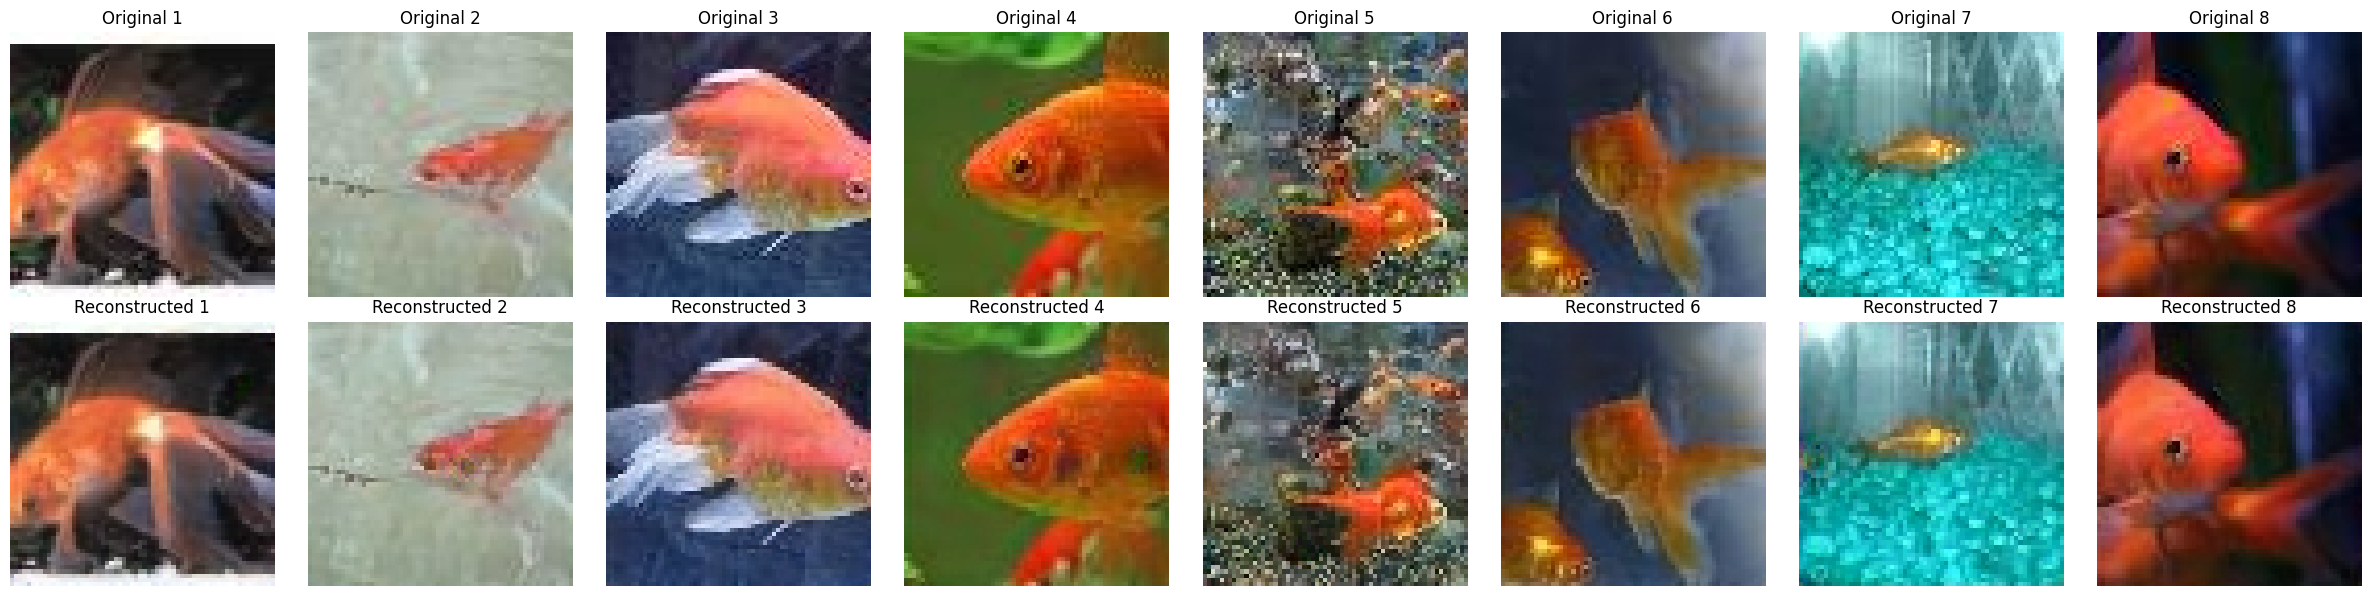

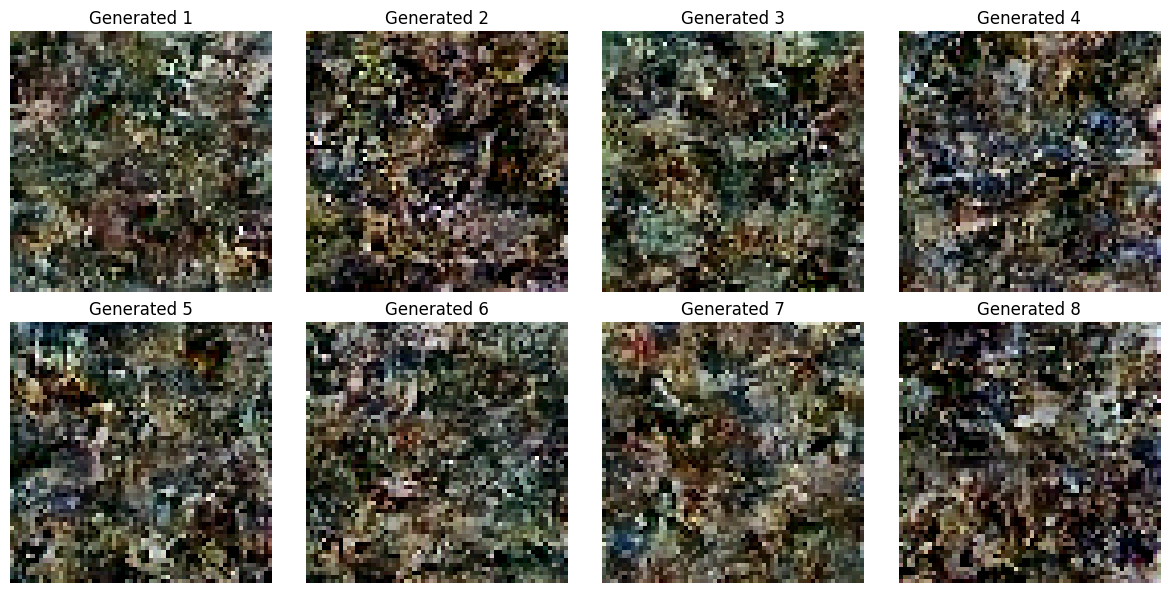

/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `SSIM` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `FrechetInceptionDistance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



test evaluation results
  L1    : 0.067595
  MSE   : 0.010000
  LPIPS : 0.082579
  PSNR  : 26.2423 dB
  SSIM  : 0.909572
  FID   : 6.8371
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 2812/2812 [07:27<00:00,  6.29it/s, rec=0.2063, g=3.2160, d=N/A, KL=2620.2476]    



Epoch 1/10 [vae]
  Train - Rec: 0.2657, Reg(vae): 2487.5068, Disc: 0.0154
  Val   - Rec Loss: 0.2089
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.2089)


Epoch 2 [vae]: 100%|██████████| 2812/2812 [10:12<00:00,  4.59it/s, rec=0.1628, g=4.2109, d=0.0756, KL=3401.0596] 


...


Epoch 8/10 [vae]
  Train - Rec: 0.0984, Reg(vae): 4285.1546, Disc: 0.0037
  Val   - Rec Loss: 0.0968
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0968)


Epoch 9 [vae]: 100%|██████████| 2812/2812 [09:47<00:00,  4.79it/s, rec=0.1000, g=2.0198, d=0.0002, KL=4453.3506]



Epoch 9/10 [vae]
  Train - Rec: 0.0946, Reg(vae): 4333.5870, Disc: 0.0003
  Val   - Rec Loss: 0.0940
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0940)


Epoch 10 [vae]: 100%|██████████| 2812/2812 [09:42<00:00,  4.83it/s, rec=0.0974, g=3.3814, d=N/A, KL=4393.5757]   



Epoch 10/10 [vae]
  Train - Rec: 0.0922, Reg(vae): 4358.8823, Disc: 0.0001
  Val   - Rec Loss: 0.0921
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0921)

[vae] 训练完成! 最佳验证损失: 0.0921


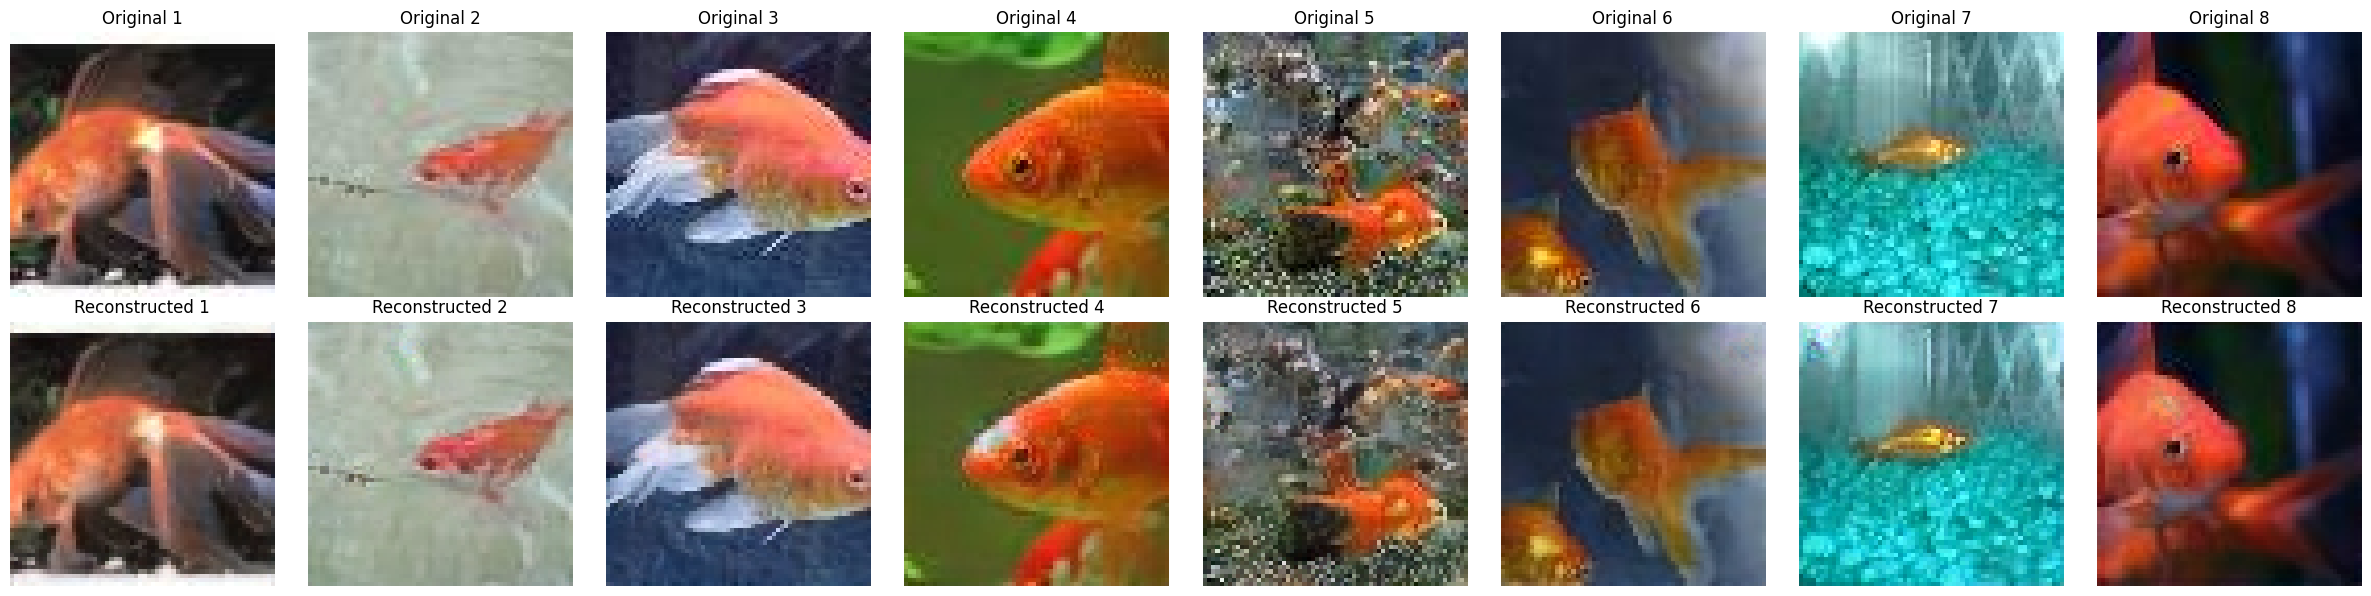

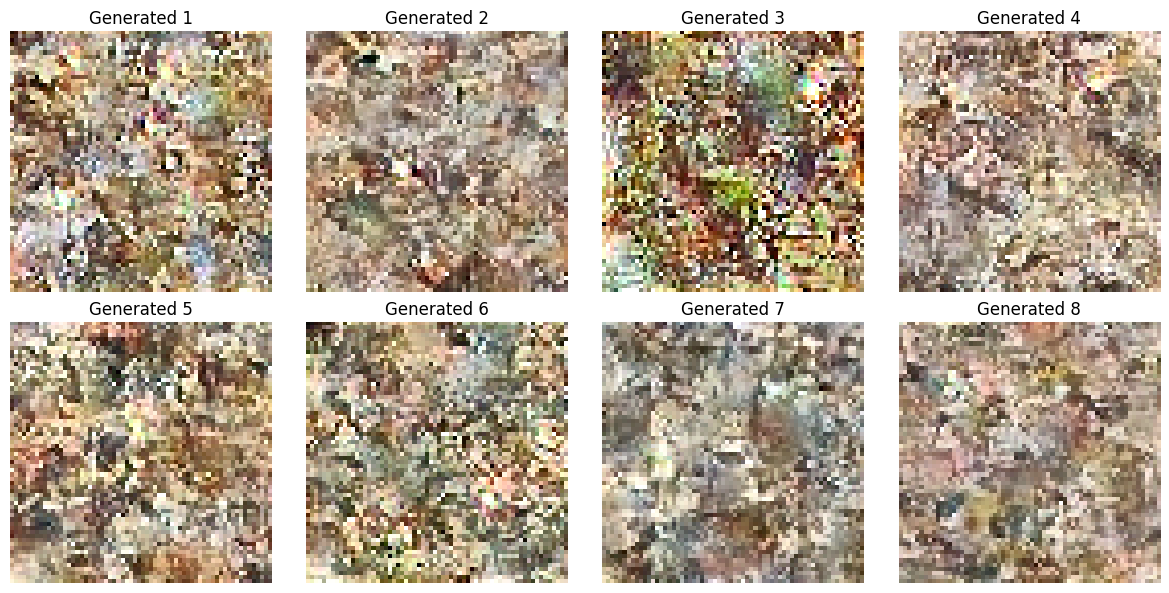


test evaluation results
  L1    : 0.069627
  MSE   : 0.010553
  LPIPS : 0.087603
  PSNR  : 25.9787 dB
  SSIM  : 0.903282
  FID   : 7.3461
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 2812/2812 [07:25<00:00,  6.32it/s, rec=0.1959, g=2.8124, d=0.0003, KL=3100.3350] 



Epoch 1/10 [vae]
  Train - Rec: 0.2562, Reg(vae): 2733.6767, Disc: 0.0214
  Val   - Rec Loss: 0.1933
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1933)


Epoch 2 [vae]: 100%|██████████| 2812/2812 [09:44<00:00,  4.81it/s, rec=0.1467, g=2.1995, d=0.7411, KL=3631.5488] 



Epoch 2/10 [vae]
  Train - Rec: 0.1673, Reg(vae): 3541.9760, Disc: 0.2072
  Val   - Rec Loss: 0.1584
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1584)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0948, Reg(vae): 4443.5348, Disc: 0.0015
  Val   - Rec Loss: 0.0939
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0939)


Epoch 9 [vae]: 100%|██████████| 2812/2812 [09:48<00:00,  4.78it/s, rec=0.0932, g=4.1014, d=N/A, KL=4481.1592]   



Epoch 9/10 [vae]
  Train - Rec: 0.0921, Reg(vae): 4455.2852, Disc: 0.0001
  Val   - Rec Loss: 0.0938
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0938)


Epoch 10 [vae]: 100%|██████████| 2812/2812 [09:19<00:00,  5.02it/s, rec=0.0940, g=5.6681, d=N/A, KL=4522.6323]   



Epoch 10/10 [vae]
  Train - Rec: 0.0904, Reg(vae): 4460.4427, Disc: 0.0000
  Val   - Rec Loss: 0.0905
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0905)

[vae] 训练完成! 最佳验证损失: 0.0905


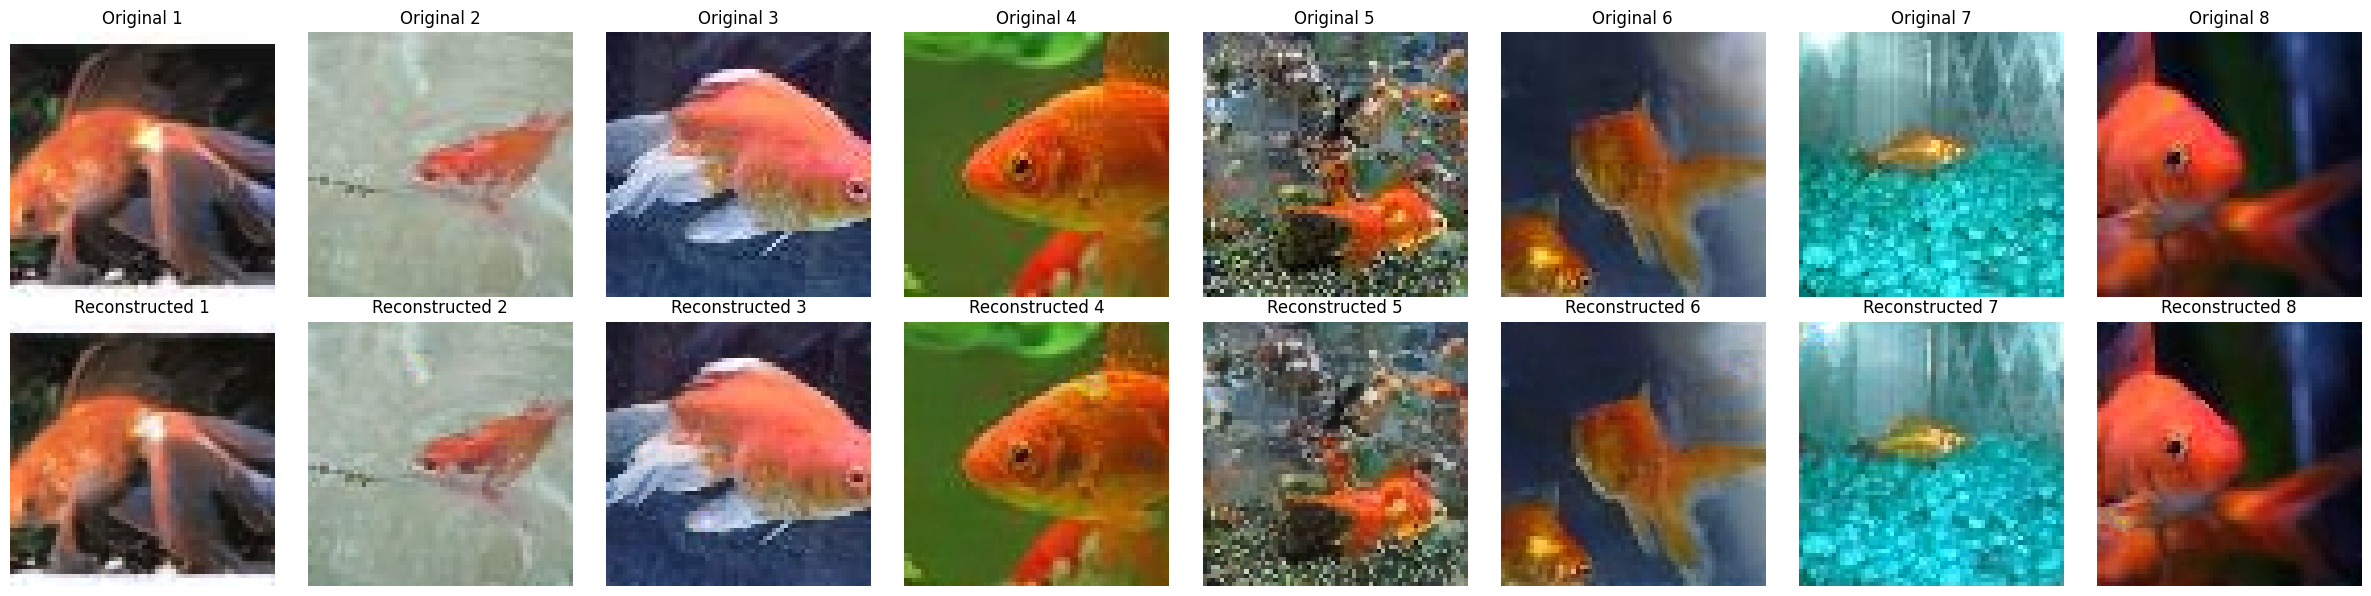

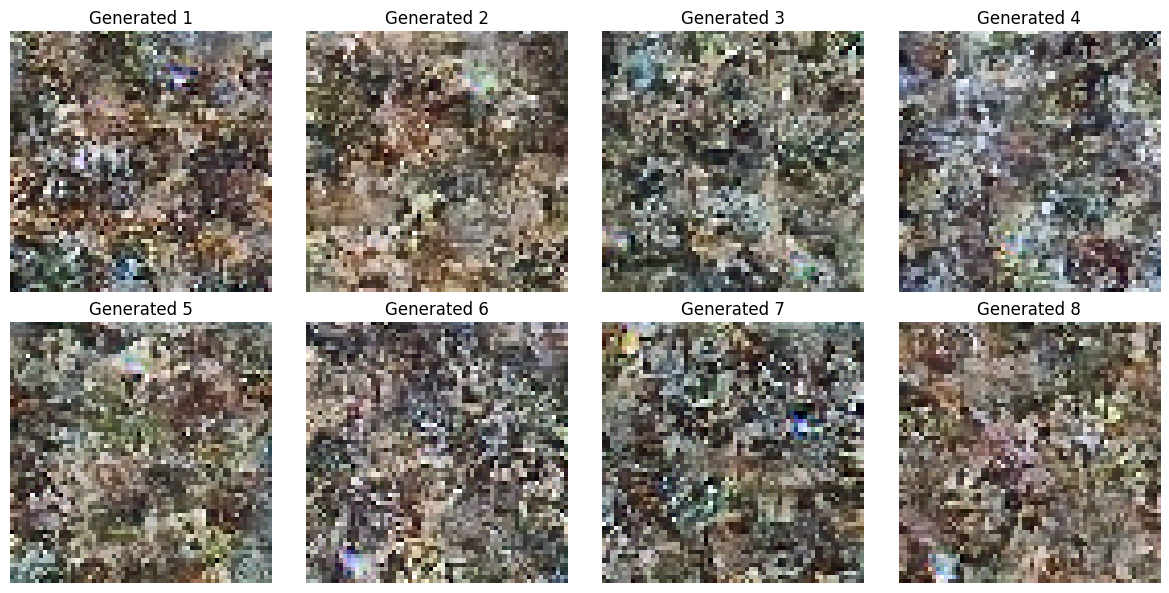


test evaluation results
  L1    : 0.068986
  MSE   : 0.010283
  LPIPS : 0.084329
  PSNR  : 26.1177 dB
  SSIM  : 0.908197
  FID   : 7.2398
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[vae] 最终评估完成。
[vae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [vae] (run_tag=vae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*KL + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [vae]: 100%|██████████| 2812/2812 [07:16<00:00,  6.45it/s, rec=0.1635, g=4.2719, d=0.0387, KL=3641.7339] 



Epoch 1/10 [vae]
  Train - Rec: 0.2477, Reg(vae): 2997.3943, Disc: 0.0345
  Val   - Rec Loss: 0.1707
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1707)


Epoch 2 [vae]: 100%|██████████| 2812/2812 [09:31<00:00,  4.92it/s, rec=0.1528, g=-0.9116, d=1.6958, KL=3726.6082]



Epoch 2/10 [vae]
  Train - Rec: 0.1587, Reg(vae): 3674.5077, Disc: 0.1517
  Val   - Rec Loss: 0.1520
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1520)


...


Epoch 8/10 [vae]
  Train - Rec: 0.0929, Reg(vae): 4542.6435, Disc: 0.0007
  Val   - Rec Loss: 0.0912
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0912)


Epoch 9 [vae]: 100%|██████████| 2812/2812 [09:22<00:00,  5.00it/s, rec=0.1042, g=4.8059, d=N/A, KL=4607.6362]   



Epoch 9/10 [vae]
  Train - Rec: 0.0902, Reg(vae): 4557.1932, Disc: 0.0001
  Val   - Rec Loss: 0.0897
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0897)


Epoch 10 [vae]: 100%|██████████| 2812/2812 [09:54<00:00,  4.73it/s, rec=0.0800, g=5.1042, d=N/A, KL=4470.2402]   



Epoch 10/10 [vae]
  Train - Rec: 0.0882, Reg(vae): 4562.5992, Disc: 0.0000
  Val   - Rec Loss: 0.0897
  AE LR: 1.44e-05
  Global Step: 28120

[vae] 训练完成! 最佳验证损失: 0.0897


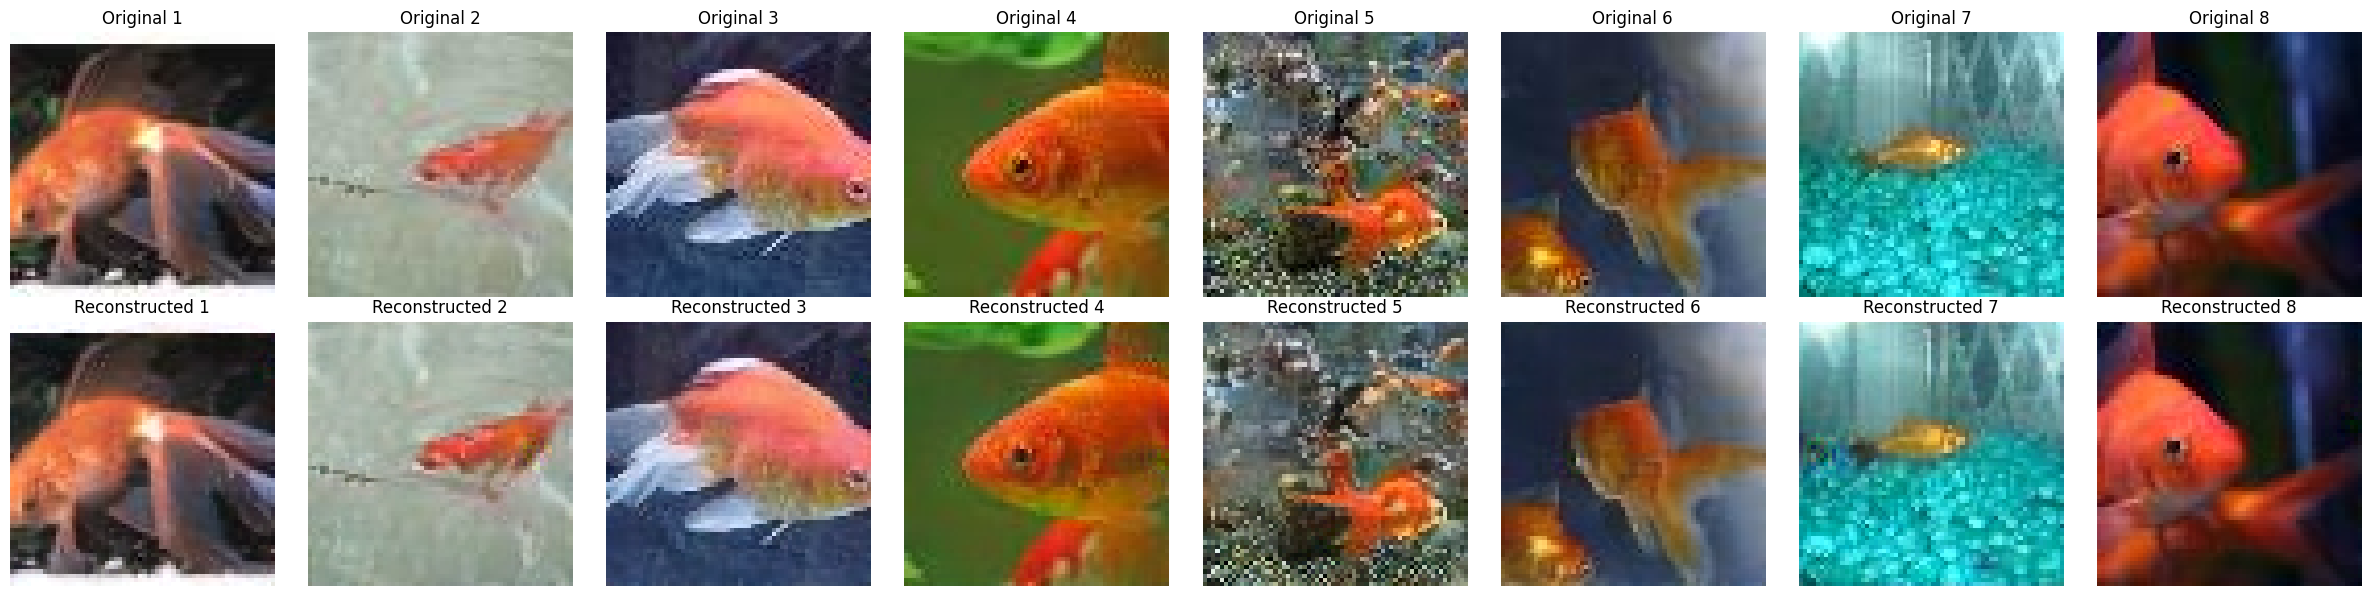

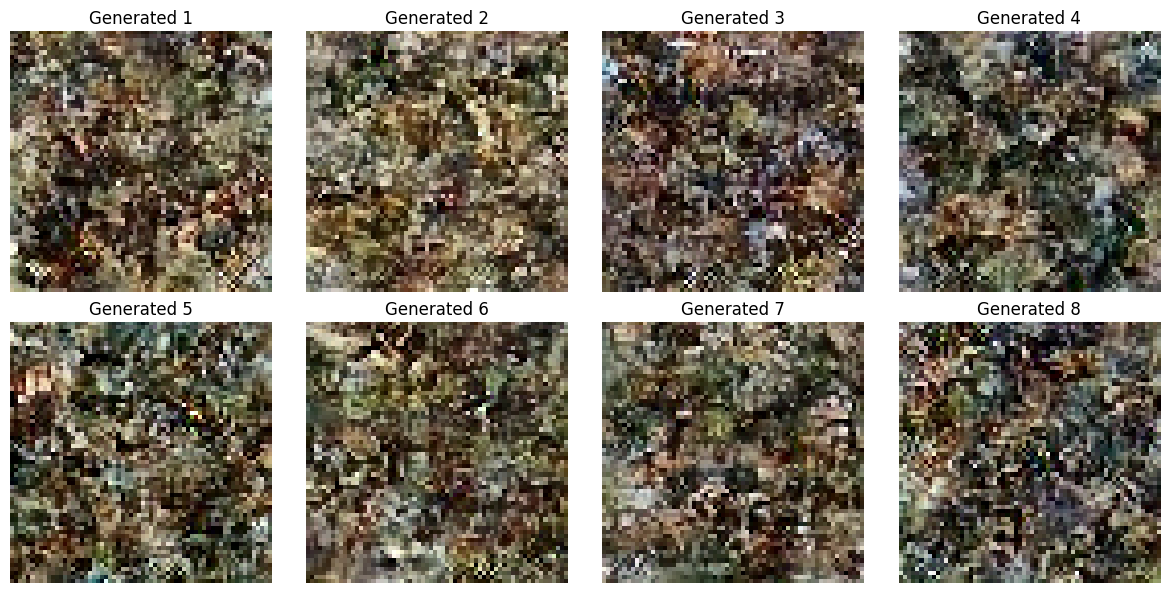


test evaluation results
  L1    : 0.068499
  MSE   : 0.010151
  LPIPS : 0.082091
  PSNR  : 26.1671 dB
  SSIM  : 0.910557
  FID   : 6.7950
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/vae_kl_1e-05/eval_test_vae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[vae] 最终评估完成。


In [16]:
for w in [1e-5]:
    for rep in range(4): 
        _ = run_training("vae", kl_weight=w, run_tag=f"vae_kl_{w:.0e}")


### run sd (ours)

[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on tiny-image-net
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 2812/2812 [28:07<00:00,  1.67it/s, rec=0.1936, g=3.1002, d=N/A, Dq=-2272.4368, KLt=176915.8750]    



Epoch 1/10 [sd]
  Train - Rec: 0.2604, Reg(sd): -0.0238, Disc: 0.0154
  Val   - Rec Loss: 0.1923
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1923)


Epoch 2 [sd]: 100%|██████████| 2812/2812 [30:35<00:00,  1.53it/s, rec=0.1631, g=4.4328, d=0.4779, Dq=-1851.1775, KLt=67818.6953] 



Epoch 2/10 [sd]
  Train - Rec: 0.1786, Reg(sd): -0.0217, Disc: 0.0300
  Val   - Rec Loss: 0.1534
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1534)


...


Epoch 8/10 [sd]
  Train - Rec: 0.0870, Reg(sd): -0.0127, Disc: 0.0267
  Val   - Rec Loss: 0.0834
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0834)


Epoch 9 [sd]: 100%|██████████| 2812/2812 [30:47<00:00,  1.52it/s, rec=0.0852, g=0.4050, d=0.1898, Dq=-1053.4266, KLt=17575.4941] 



Epoch 9/10 [sd]
  Train - Rec: 0.0782, Reg(sd): -0.0109, Disc: 0.0073
  Val   - Rec Loss: 0.0765
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0765)


Epoch 10 [sd]: 100%|██████████| 2812/2812 [30:40<00:00,  1.53it/s, rec=0.0762, g=3.5434, d=N/A, Dq=-1032.7241, KLt=11031.6553]    



Epoch 10/10 [sd]
  Train - Rec: 0.0739, Reg(sd): -0.0104, Disc: 0.0017
  Val   - Rec Loss: 0.0732
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0732)

[sd] 训练完成! 最佳验证损失: 0.0732


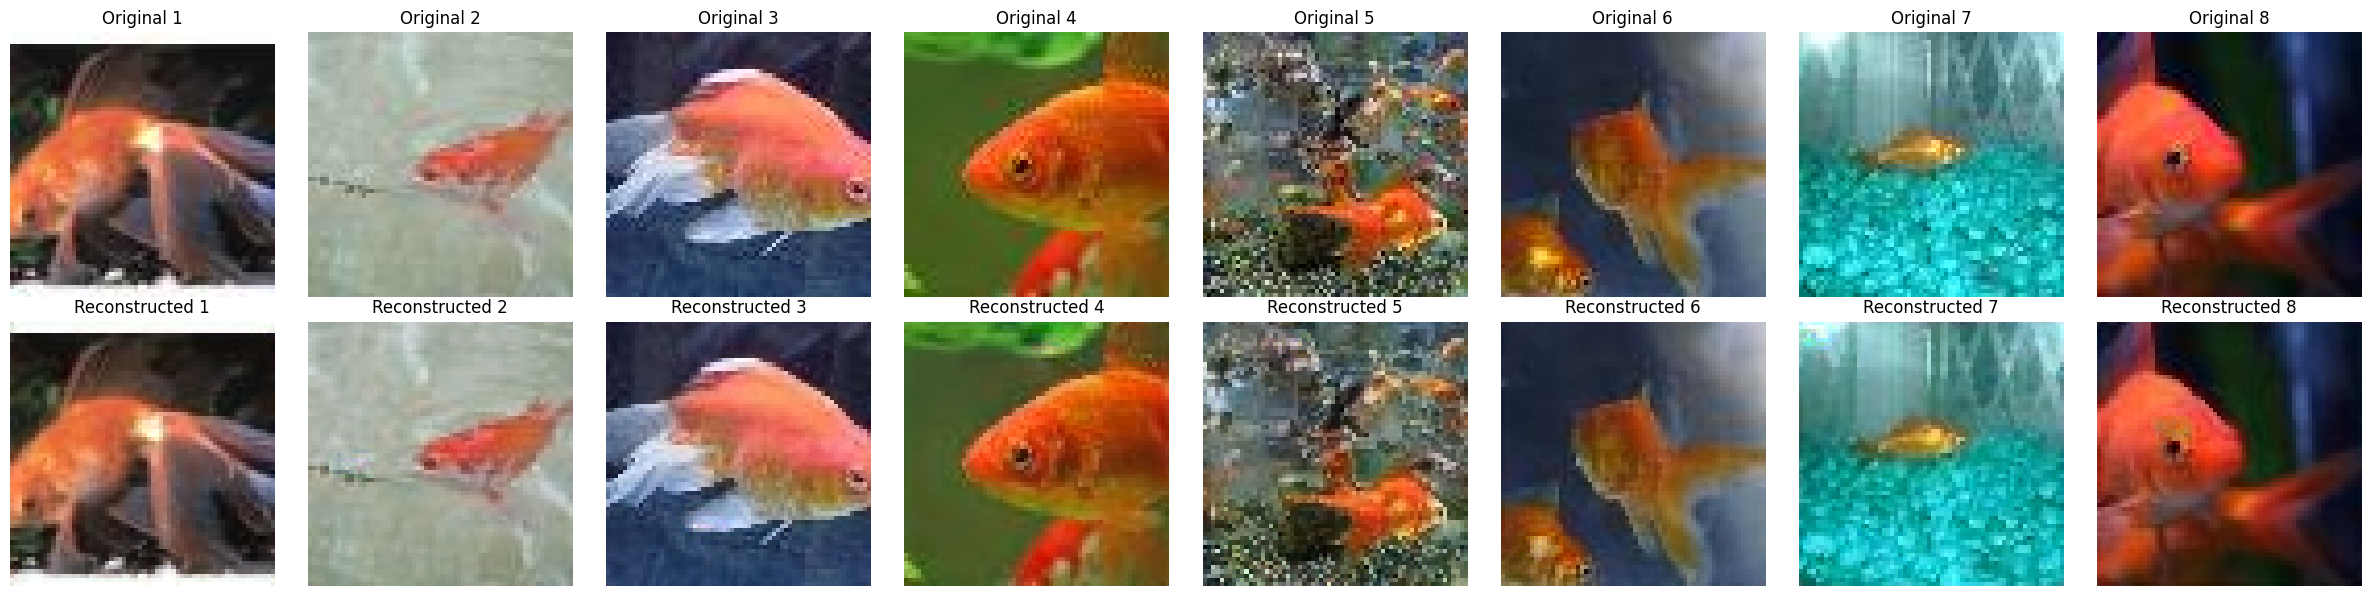

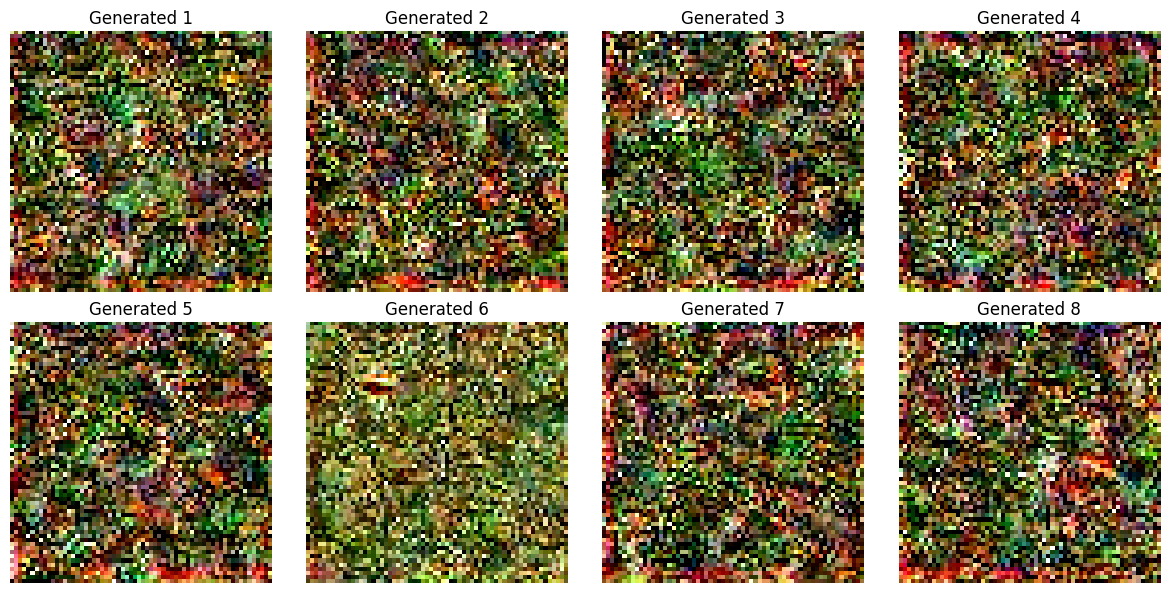


test evaluation results
  L1    : 0.057563
  MSE   : 0.008164
  LPIPS : 0.060138
  PSNR  : 27.1341 dB
  SSIM  : 0.931334
  FID   : 5.5667
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on tiny-image-net
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 2812/2812 [28:30<00:00,  1.64it/s, rec=0.2075, g=4.2039, d=0.0002, Dq=-1636.4917, KLt=192193.0312] 



Epoch 1/10 [sd]
  Train - Rec: 0.2536, Reg(sd): -0.0140, Disc: 0.0214
  Val   - Rec Loss: 0.1981
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1981)


Epoch 2 [sd]: 100%|██████████| 2812/2812 [30:41<00:00,  1.53it/s, rec=0.1503, g=2.6174, d=0.1871, Dq=-1745.9824, KLt=96329.7188] 



Epoch 2/10 [sd]
  Train - Rec: 0.1651, Reg(sd): -0.0165, Disc: 0.1245
  Val   - Rec Loss: 0.1429
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1429)


...


Epoch 8/10 [sd]
  Train - Rec: 0.1017, Reg(sd): -0.0137, Disc: 0.0406
  Val   - Rec Loss: 0.0967
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0967)


Epoch 9 [sd]: 100%|██████████| 2812/2812 [30:54<00:00,  1.52it/s, rec=0.0883, g=1.0745, d=0.0838, Dq=-1182.3989, KLt=22506.0254]



Epoch 9/10 [sd]
  Train - Rec: 0.0905, Reg(sd): -0.0121, Disc: 0.0066
  Val   - Rec Loss: 0.0888
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0888)


Epoch 10 [sd]: 100%|██████████| 2812/2812 [30:16<00:00,  1.55it/s, rec=0.0846, g=3.8381, d=N/A, Dq=-1135.1925, KLt=12337.6250]    



Epoch 10/10 [sd]
  Train - Rec: 0.0838, Reg(sd): -0.0113, Disc: 0.0014
  Val   - Rec Loss: 0.0824
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0824)

[sd] 训练完成! 最佳验证损失: 0.0824


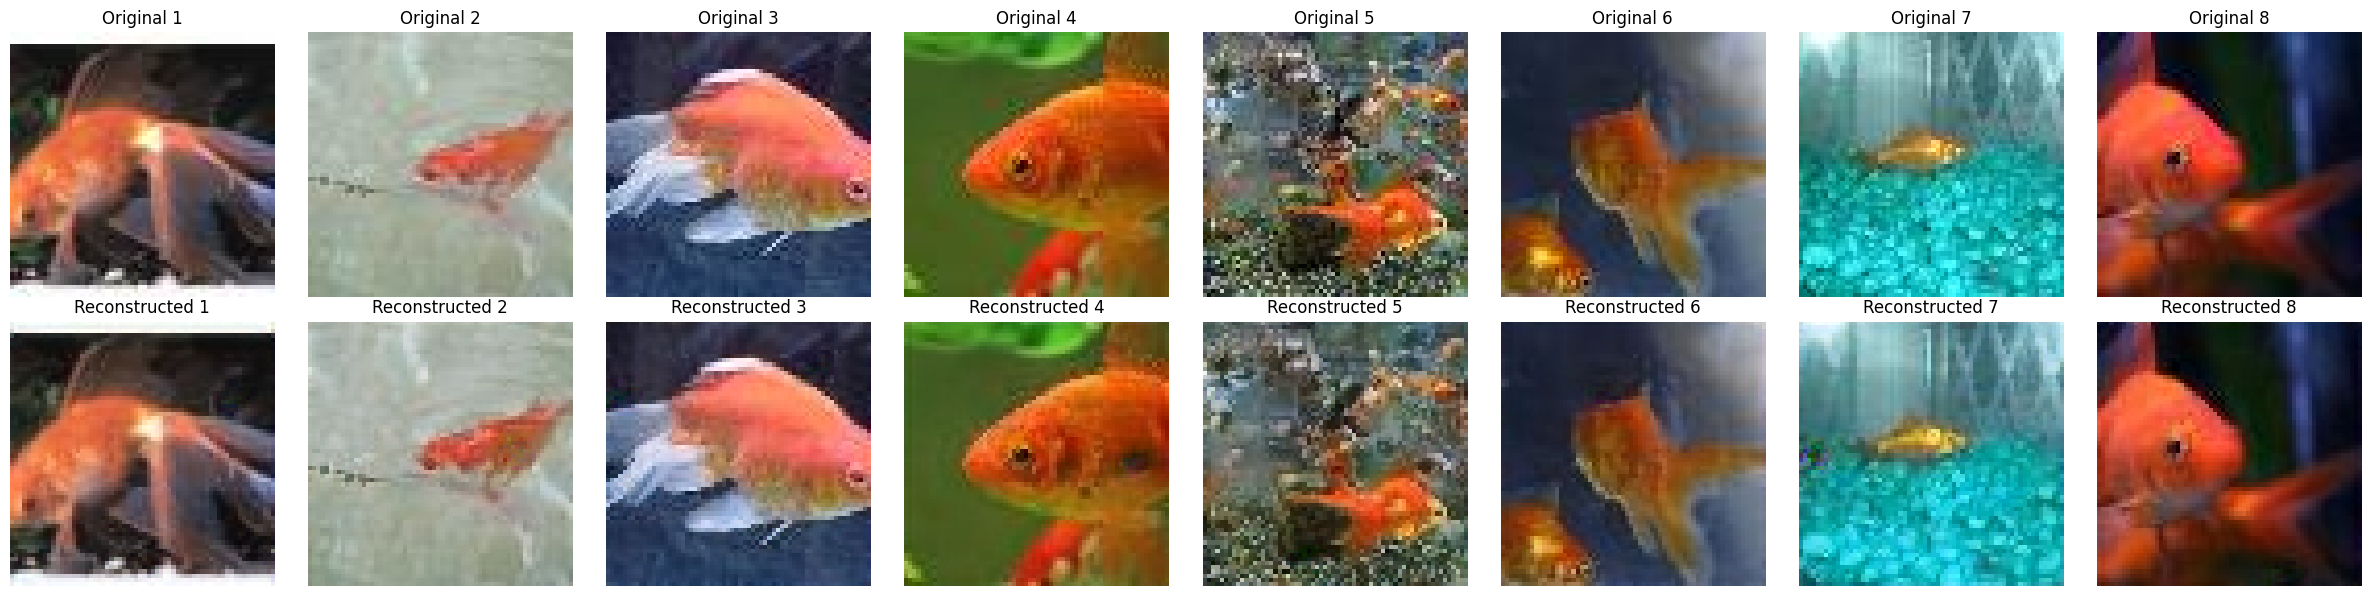

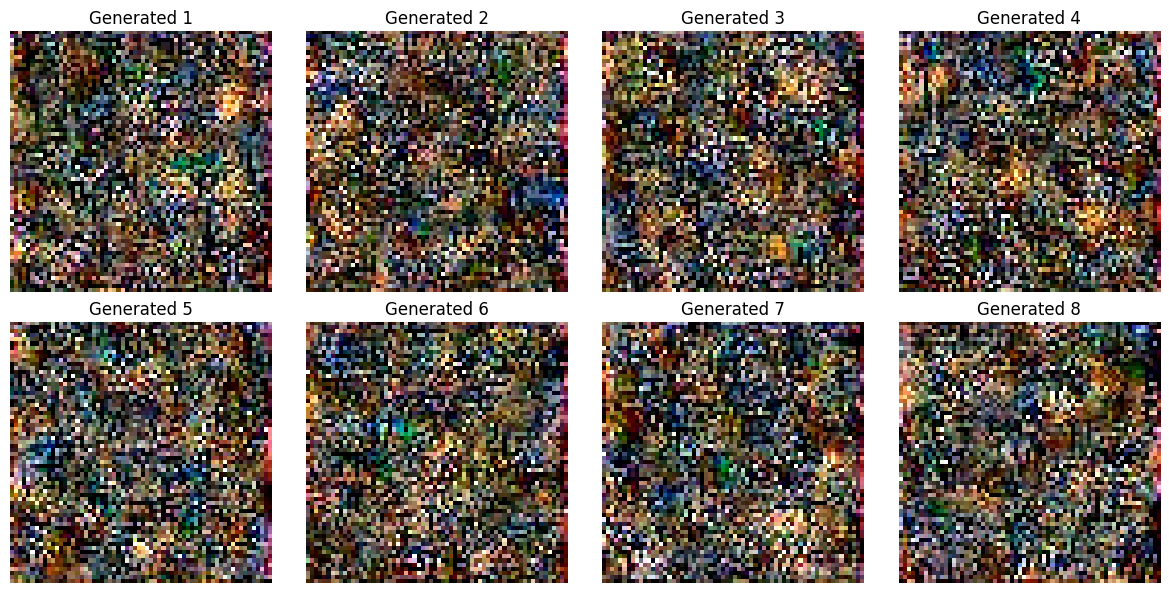


test evaluation results
  L1    : 0.063385
  MSE   : 0.009564
  LPIPS : 0.073284
  PSNR  : 26.4734 dB
  SSIM  : 0.917931
  FID   : 6.1747
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/dq_1e-05_klt_1e-08/eval_test_dq_1e-05_klt_1e-08.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[sd] 最终评估完成。
[sd] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [sd] (run_tag=dq_1e-05_klt_1e-08) on tiny-image-net
损失函数: L_rec + (...) = L_rec + eff_dq(1.000e-05)*Dq + eff_klt(1.000e-08)*KL_t + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [sd]: 100%|██████████| 2812/2812 [28:06<00:00,  1.67it/s, rec=0.2014, g=3.2239, d=0.0001, Dq=-2443.9712, KLt=183791.0938] 



Epoch 1/10 [sd]
  Train - Rec: 0.2561, Reg(sd): -0.0230, Disc: 0.0159
  Val   - Rec Loss: 0.2014
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.2014)


Epoch 2 [sd]: 100%|██████████| 2812/2812 [30:26<00:00,  1.54it/s, rec=0.1674, g=5.6259, d=0.0002, Dq=-2276.6099, KLt=34274.6641] 



Epoch 2/10 [sd]
  Train - Rec: 0.1808, Reg(sd): -0.0231, Disc: 0.0498
  Val   - Rec Loss: 0.1668
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1668)


...

Epoch 6 [sd]: 100%|██████████| 2812/2812 [30:44<00:00,  1.52it/s, rec=0.0996, g=3.8072, d=N/A, Dq=-1770.6918, KLt=25188.2500]    



Epoch 6/10 [sd]
  Train - Rec: 0.1062, Reg(sd): -0.0175, Disc: 0.1145
  Val   - Rec Loss: 0.1019
  AE LR: 5.92e-05
  Global Step: 16872
  ✓ 保存最佳模型 (val_loss: 0.1019)


Epoch 7 [sd]: 100%|██████████| 2812/2812 [30:35<00:00,  1.53it/s, rec=0.1007, g=3.4501, d=0.0001, Dq=-1704.7843, KLt=16742.9629] 



Epoch 7/10 [sd]
  Train - Rec: 0.1000, Reg(sd): -0.0171, Disc: 0.0244
  Val   - Rec Loss: 0.1012
  AE LR: 4.11e-05
  Global Step: 19684
  ✓ 保存最佳模型 (val_loss: 0.1012)


Epoch 8 [sd]: 100%|██████████| 2812/2812 [30:27<00:00,  1.54it/s, rec=0.0997, g=4.3138, d=N/A, Dq=-1608.0339, KLt=12854.7471]    


In [ ]:
for klt_w in [1e-8]:
    for dq_w in [1e-5]:
        for rep in range(4): 
            _ = run_training("sd", 
                            sd_dq_weight=dq_w, 
                            sd_klt_weight=klt_w,  
                            run_tag=f"dq_{dq_w:.0e}_klt_{klt_w:.0e}")


### run iwae

[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 2812/2812 [13:15<00:00,  3.53it/s, rec=0.1792, g=2.6772, d=0.0043, IWAE=15074.2012] 



Epoch 1/10 [iwae]
  Train - Rec: 0.2461, Reg(iwae): 14443.8711, Disc: 0.0361
  Val   - Rec Loss: 0.1811
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1811)


Epoch 2 [iwae]: 100%|██████████| 2812/2812 [15:39<00:00,  2.99it/s, rec=0.1379, g=2.1040, d=0.0847, IWAE=15494.7695] 



Epoch 2/10 [iwae]
  Train - Rec: 0.1597, Reg(iwae): 15234.0330, Disc: 0.2789
  Val   - Rec Loss: 0.1454
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1454)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0949, Reg(iwae): 15906.8923, Disc: 0.0027
  Val   - Rec Loss: 0.0949
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0949)


Epoch 9 [iwae]: 100%|██████████| 2812/2812 [15:48<00:00,  2.97it/s, rec=0.0953, g=3.6159, d=N/A, IWAE=15969.8066]   



Epoch 9/10 [iwae]
  Train - Rec: 0.0919, Reg(iwae): 15899.9966, Disc: 0.0003
  Val   - Rec Loss: 0.0915
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0915)


Epoch 10 [iwae]: 100%|██████████| 2812/2812 [16:05<00:00,  2.91it/s, rec=0.0904, g=5.3549, d=N/A, IWAE=15909.1367]   



Epoch 10/10 [iwae]
  Train - Rec: 0.0898, Reg(iwae): 15894.8398, Disc: 0.0000
  Val   - Rec Loss: 0.0898
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0898)

[iwae] 训练完成! 最佳验证损失: 0.0898


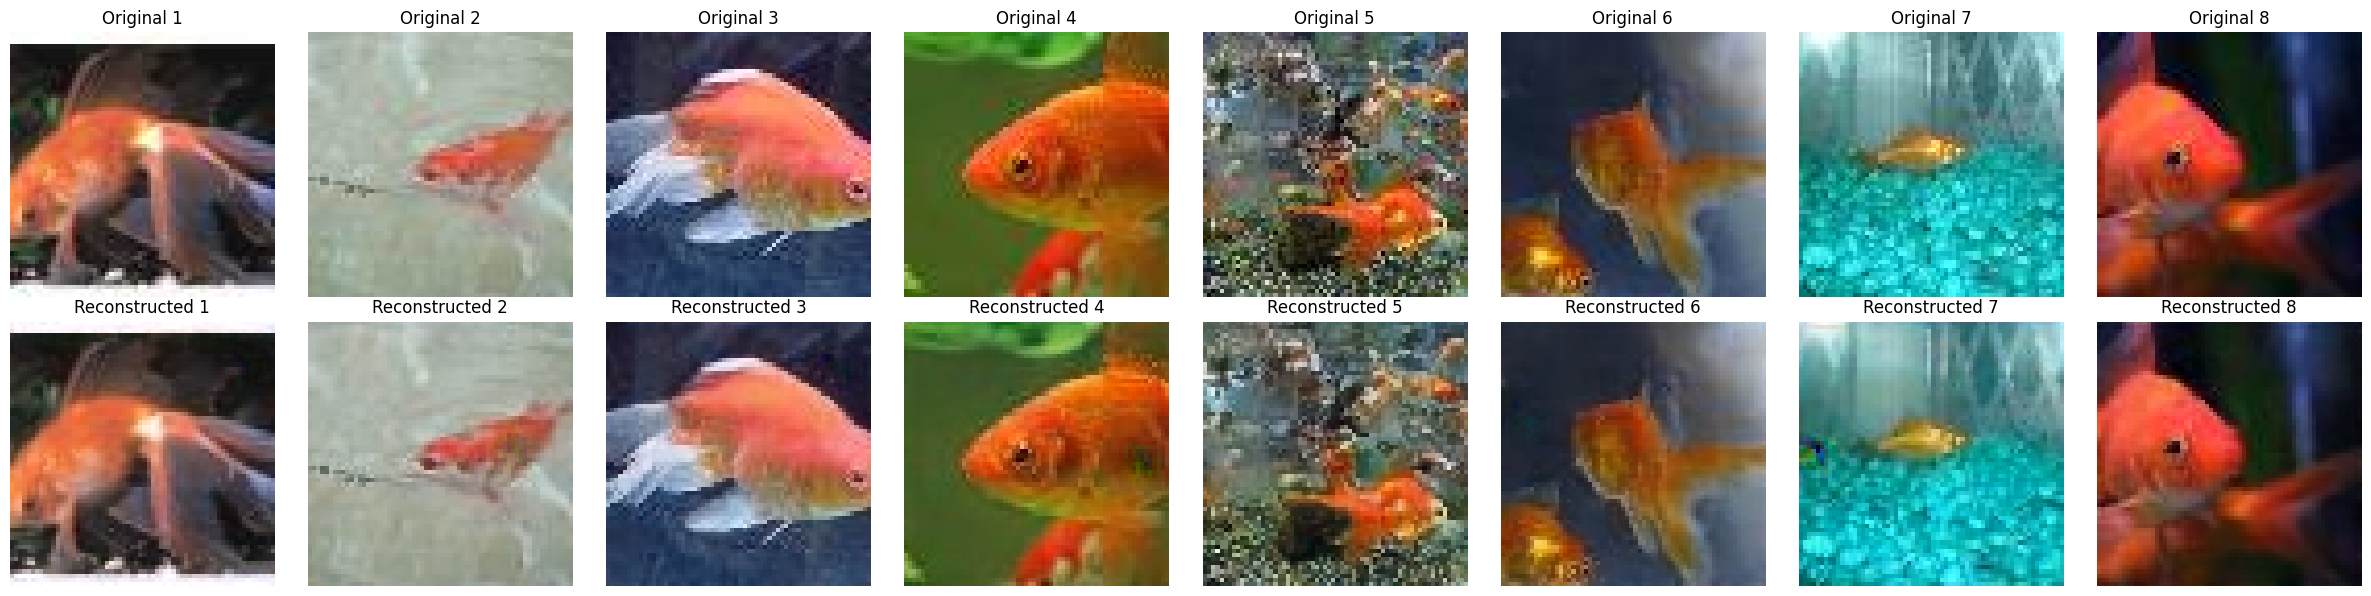

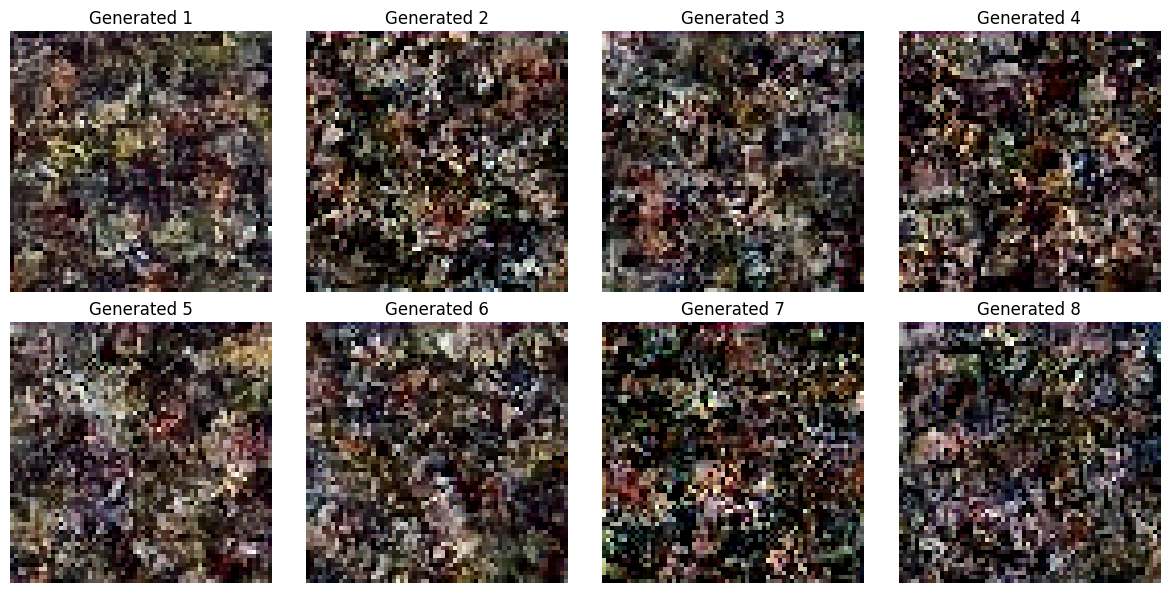

/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `SSIM` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
/home/yzm/anaconda3/envs/gen/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:36: UserWarning: Metric `FrechetInceptionDistance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



test evaluation results
  L1    : 0.067896
  MSE   : 0.009942
  LPIPS : 0.085196
  PSNR  : 26.2378 dB
  SSIM  : 0.909223
  FID   : 6.5208
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 2812/2812 [13:44<00:00,  3.41it/s, rec=0.1826, g=2.9677, d=0.0000, IWAE=14766.5205] 



Epoch 1/10 [iwae]
  Train - Rec: 0.2495, Reg(iwae): 14379.4898, Disc: 0.0245
  Val   - Rec Loss: 0.1834
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1834)


Epoch 2 [iwae]: 100%|██████████| 2812/2812 [15:50<00:00,  2.96it/s, rec=0.1457, g=1.2353, d=0.1119, IWAE=15076.8330] 


...


Epoch 8/10 [iwae]
  Train - Rec: 0.0951, Reg(iwae): 15807.5293, Disc: 0.0011
  Val   - Rec Loss: 0.0928
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0928)


Epoch 9 [iwae]: 100%|██████████| 2812/2812 [16:19<00:00,  2.87it/s, rec=0.0904, g=5.2255, d=N/A, IWAE=15787.6562]   



Epoch 9/10 [iwae]
  Train - Rec: 0.0918, Reg(iwae): 15824.1922, Disc: 0.0001
  Val   - Rec Loss: 0.0922
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0922)


Epoch 10 [iwae]: 100%|██████████| 2812/2812 [16:19<00:00,  2.87it/s, rec=0.0825, g=6.4518, d=N/A, IWAE=15780.5635]   



Epoch 10/10 [iwae]
  Train - Rec: 0.0899, Reg(iwae): 15830.3587, Disc: 0.0000
  Val   - Rec Loss: 0.0897
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0897)

[iwae] 训练完成! 最佳验证损失: 0.0897


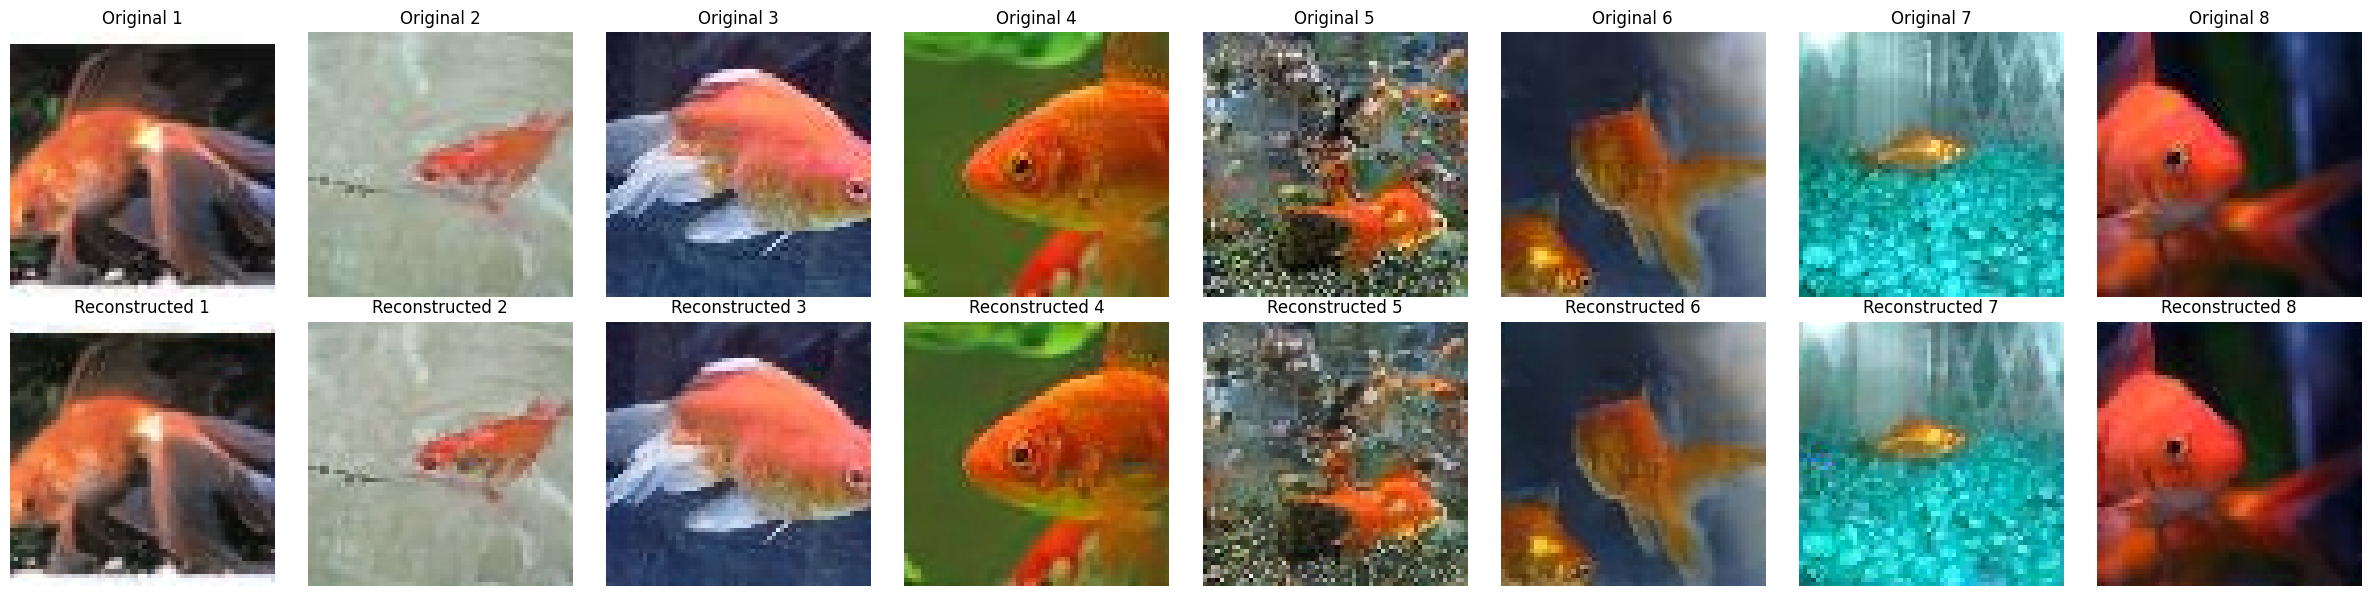

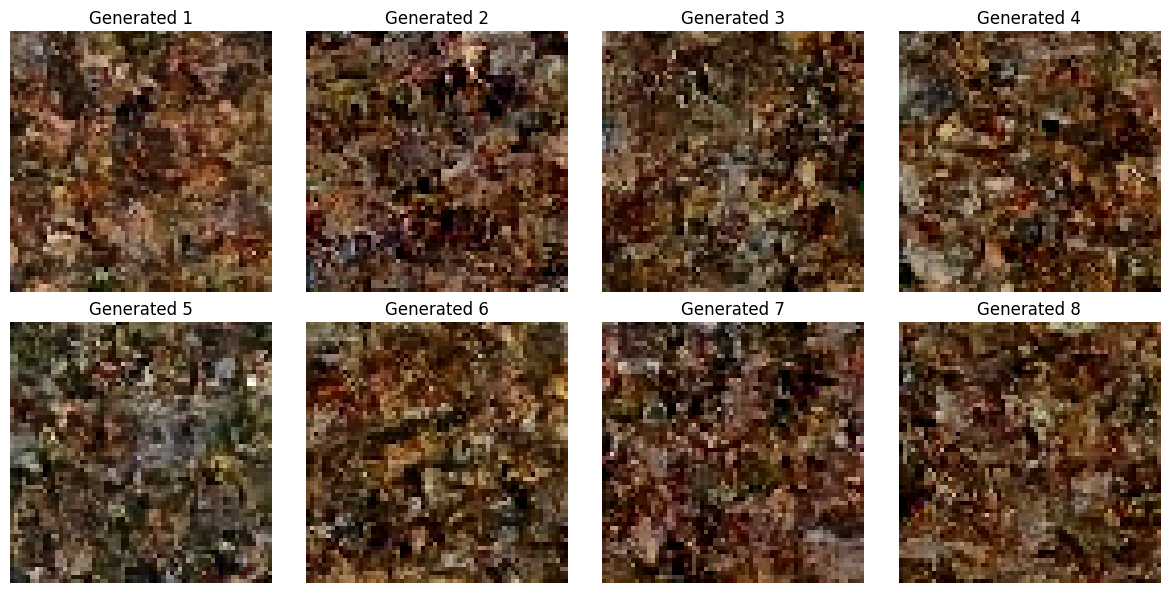


test evaluation results
  L1    : 0.068543
  MSE   : 0.010196
  LPIPS : 0.083286
  PSNR  : 26.1593 dB
  SSIM  : 0.909394
  FID   : 7.1446
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 2812/2812 [13:52<00:00,  3.38it/s, rec=0.1803, g=3.0239, d=N/A, IWAE=14871.4561]    



Epoch 1/10 [iwae]
  Train - Rec: 0.2512, Reg(iwae): 14267.9782, Disc: 0.0281
  Val   - Rec Loss: 0.1796
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.1796)


Epoch 2 [iwae]: 100%|██████████| 2812/2812 [16:48<00:00,  2.79it/s, rec=0.1556, g=0.3299, d=1.2064, IWAE=15193.8584] 



Epoch 2/10 [iwae]
  Train - Rec: 0.1652, Reg(iwae): 15108.4774, Disc: 0.3879
  Val   - Rec Loss: 0.1640
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1640)


...


Epoch 8/10 [iwae]
  Train - Rec: 0.1015, Reg(iwae): 15878.5228, Disc: 0.0037
  Val   - Rec Loss: 0.0998
  AE LR: 2.68e-05
  Global Step: 22496
  ✓ 保存最佳模型 (val_loss: 0.0998)


Epoch 9 [iwae]: 100%|██████████| 2812/2812 [15:07<00:00,  3.10it/s, rec=0.0946, g=3.9170, d=N/A, IWAE=15863.3633]   



Epoch 9/10 [iwae]
  Train - Rec: 0.0974, Reg(iwae): 15889.4698, Disc: 0.0007
  Val   - Rec Loss: 0.0976
  AE LR: 1.76e-05
  Global Step: 25308
  ✓ 保存最佳模型 (val_loss: 0.0976)


Epoch 10 [iwae]: 100%|██████████| 2812/2812 [15:22<00:00,  3.05it/s, rec=0.0989, g=3.1191, d=N/A, IWAE=15944.5781]   



Epoch 10/10 [iwae]
  Train - Rec: 0.0947, Reg(iwae): 15894.2427, Disc: 0.0001
  Val   - Rec Loss: 0.0948
  AE LR: 1.44e-05
  Global Step: 28120
  ✓ 保存最佳模型 (val_loss: 0.0948)

[iwae] 训练完成! 最佳验证损失: 0.0948


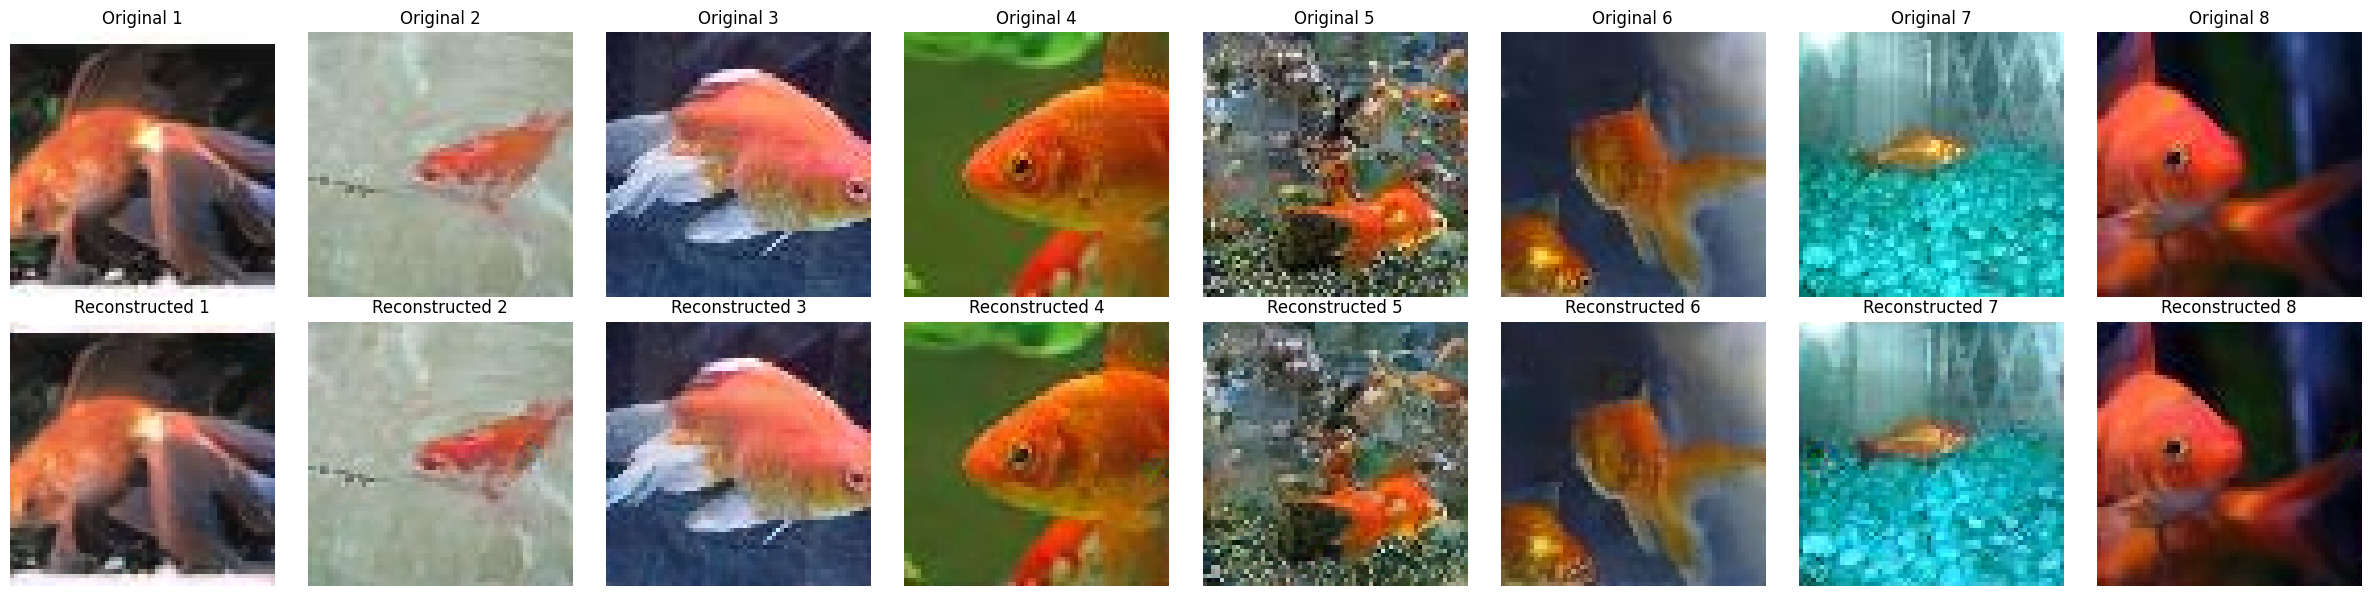

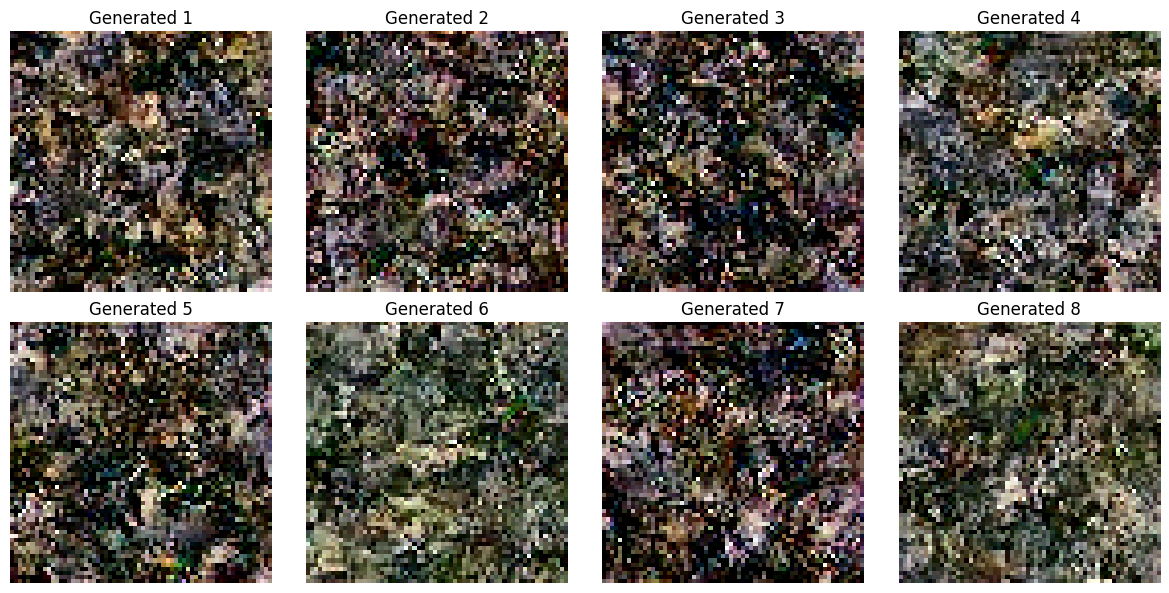


test evaluation results
  L1    : 0.071584
  MSE   : 0.011331
  LPIPS : 0.090750
  PSNR  : 25.7366 dB
  SSIM  : 0.901100
  FID   : 7.5716
评估结果已保存到: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/iwae_kl_1e-05/eval_test_iwae_kl_1e-05.json
评估结果已追加到日志: /home/yzm/ipy/checkpoints/medvae-re-tiny-image-net-06-28_18-08/medvae-re-tiny-image-net.log
[iwae] 最终评估完成。
[iwae] 模型参数量: 0.93M
Loaded pretrained LPIPS from .cache/vgg.pth
开始训练 MedVAE-re [iwae] (run_tag=iwae_kl_1e-05) on tiny-image-net
损失函数: L_rec + 1e-05*(-IWAE_bound, k=2) + d_weight*g_loss
学习率: 1.44e-04, 判别器启动步数: 2000


Epoch 1 [iwae]: 100%|██████████| 2812/2812 [13:14<00:00,  3.54it/s, rec=0.2163, g=4.2285, d=0.0015, IWAE=14311.7383] 



Epoch 1/10 [iwae]
  Train - Rec: 0.2657, Reg(iwae): 14100.6533, Disc: 0.0236
  Val   - Rec Loss: 0.2168
  AE LR: 1.41e-04
  Global Step: 2812
  ✓ 保存最佳模型 (val_loss: 0.2168)


Epoch 2 [iwae]: 100%|██████████| 2812/2812 [15:54<00:00,  2.94it/s, rec=0.1806, g=2.0482, d=0.0001, IWAE=14729.7559] 



Epoch 2/10 [iwae]
  Train - Rec: 0.1886, Reg(iwae): 14413.8223, Disc: 0.0496
  Val   - Rec Loss: 0.1700
  AE LR: 1.32e-04
  Global Step: 5624
  ✓ 保存最佳模型 (val_loss: 0.1700)


...

Epoch 6 [iwae]: 100%|██████████| 2812/2812 [16:10<00:00,  2.90it/s, rec=0.1216, g=1.2586, d=N/A, IWAE=15274.4316]    



Epoch 6/10 [iwae]
  Train - Rec: 0.1193, Reg(iwae): 15216.0429, Disc: 0.1930
  Val   - Rec Loss: 0.1118
  AE LR: 5.92e-05
  Global Step: 16872
  ✓ 保存最佳模型 (val_loss: 0.1118)


Epoch 7 [iwae]: 100%|██████████| 2812/2812 [15:56<00:00,  2.94it/s, rec=0.1076, g=2.1150, d=0.2353, IWAE=15493.8457] 



Epoch 7/10 [iwae]
  Train - Rec: 0.1094, Reg(iwae): 15413.7859, Disc: 0.0713
  Val   - Rec Loss: 0.1066
  AE LR: 4.11e-05
  Global Step: 19684
  ✓ 保存最佳模型 (val_loss: 0.1066)


Epoch 8 [iwae]: 100%|██████████| 2812/2812 [15:49<00:00,  2.96it/s, rec=0.1065, g=1.5453, d=0.1397, IWAE=15597.9980] 


In [ ]:
for w in [1e-5]:
    for rep in range(4): 
   
        _ = run_training("iwae", kl_weight=w, run_tag=f"iwae_kl_{w:.0e}")


## eof